<a href="https://colab.research.google.com/github/JuliaVillaVerde/Processamentos-de-Sinais-7P./blob/main/Aula5_Processamento_de_Sinais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**QUESTÃO 1: A transformada de Hadamard é utilizada na geração
de códigos em sistemas CDMA (code division multiple access), base do 3G. A multiplexação nos sistemas CDMA é realizada associando um código a cada usuário, sendo que cada código é ortogonal aos demais. Para avaliar o impacto da transformada de Hadamard nos sistemas CDMA, faça o que se pede nos itens abaixo.**

**Letra A: Considere um sistema CDMA com 3 usuários. Para
cada usuário, gere as sequências m1[n] ∈ {−1, 1}, m2[n] ∈ {−1, 1} e m3[n] ∈ {−1, 1} de comprimento 8.
Utilizando um código de Hadamard de comprimento 8, codifique os sinais m1[n], m2[n] e m3[n]. Mostre o gráfico do sinal original de cada usuário, do seu respectivo código e do sinal codificado. Além disso, mostre o espectro dos sinais originais e codificados e comente o impacto da codificação no espectro do sinal.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

# Set a seed for reproducibility
np.random.seed(42)

### 1. Gerando as sequências $m_1[n]$, $m_2[n]$ e $m_3[n]$ de comprimento 8

Para cada usuário, geramos uma sequência aleatória de $-1$ e $1$ de comprimento 8.

In [2]:
# Comprimento da sequência
N = 8

# Gerar sequências m1[n], m2[n], m3[n]
m1 = np.random.choice([-1, 1], size=N)
m2 = np.random.choice([-1, 1], size=N)
m3 = np.random.choice([-1, 1], size=N)

print(f"m1[n]: {m1}")
print(f"m2[n]: {m2}")
print(f"m3[n]: {m3}")

m1[n]: [-1  1 -1 -1 -1  1 -1 -1]
m2[n]: [-1  1 -1 -1 -1 -1  1 -1]
m3[n]: [ 1  1  1 -1  1 -1  1  1]


### 2. Gerando e selecionando códigos de Hadamard de comprimento 8

A matriz de Hadamard de ordem 8 contém 8 códigos ortogonais. Selecionaremos 3 deles para os usuários.

In [3]:
# Gerar a matriz de Hadamard de ordem N
H = hadamard(N)

# Selecionar 3 códigos ortogonais (linhas da matriz Hadamard)
c1 = H[1, :]
c2 = H[2, :]
c3 = H[3, :]

print(f"Código de Hadamard c1: {c1}")
print(f"Código de Hadamard c2: {c2}")
print(f"Código de Hadamard c3: {c3}")

Código de Hadamard c1: [ 1 -1  1 -1  1 -1  1 -1]
Código de Hadamard c2: [ 1  1 -1 -1  1  1 -1 -1]
Código de Hadamard c3: [ 1 -1 -1  1  1 -1 -1  1]


### 3. Codificando os sinais $m_1[n]$, $m_2[n]$ e $m_3[n]$

In [4]:
# Codificar os sinais
s1 = m1 * c1
s2 = m2 * c2
s3 = m3 * c3

print(f"Sinal codificado s1[n]: {s1}")
print(f"Sinal codificado s2[n]: {s2}")
print(f"Sinal codificado s3[n]: {s3}")

Sinal codificado s1[n]: [-1 -1 -1  1 -1 -1 -1  1]
Sinal codificado s2[n]: [-1  1  1  1 -1 -1 -1  1]
Sinal codificado s3[n]: [ 1 -1 -1 -1  1  1 -1  1]


### 4. Gráficos do sinal original, código e sinal codificado para cada usuário

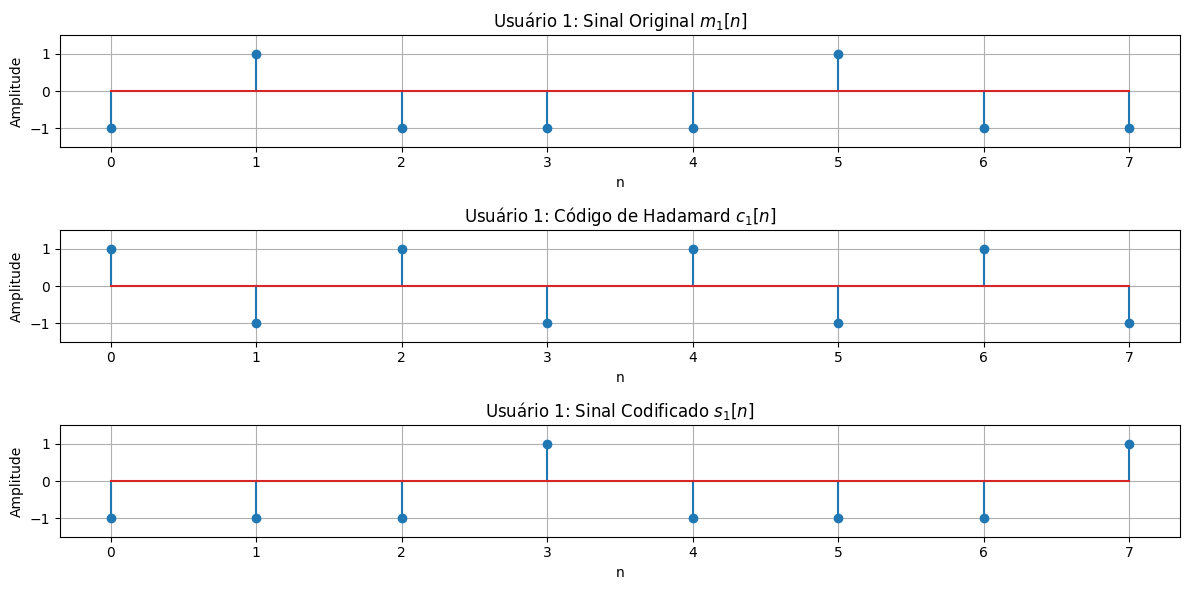

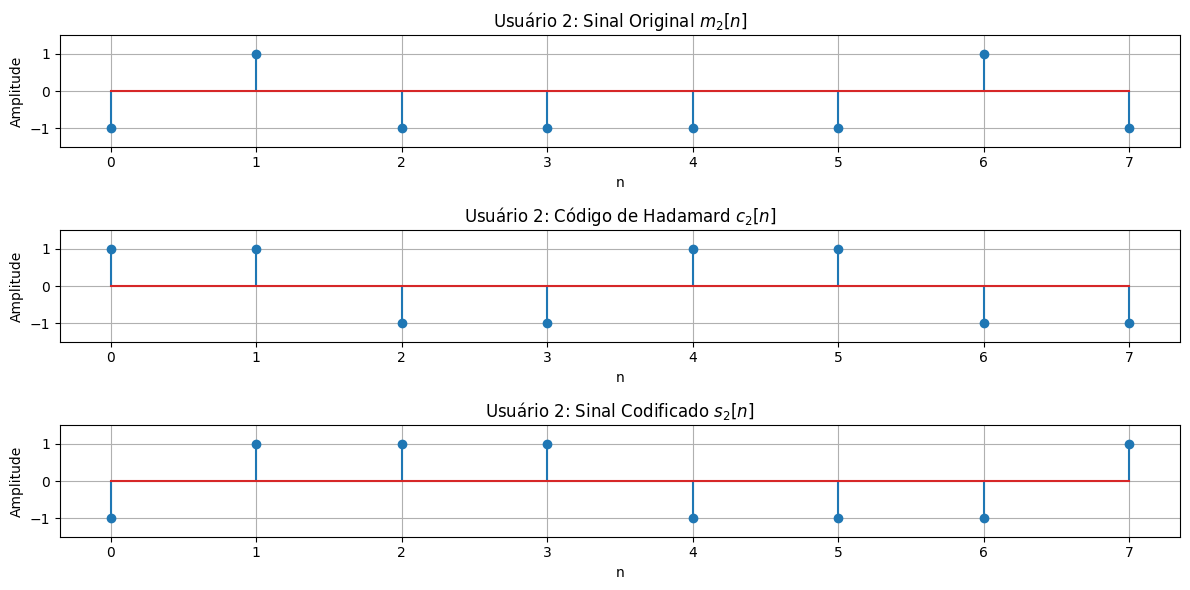

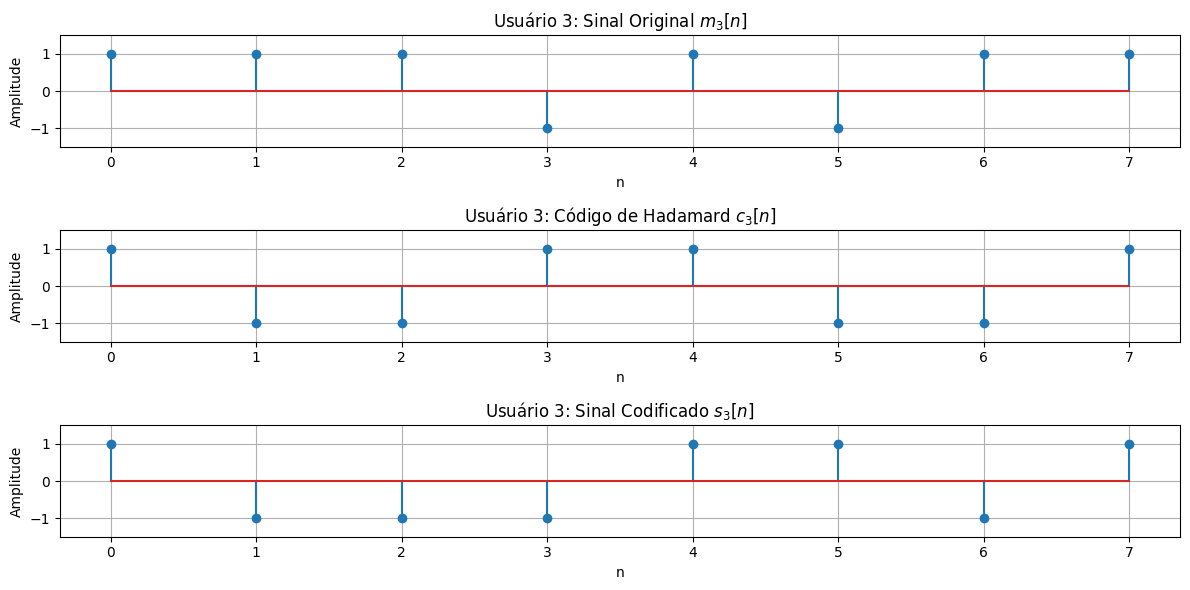

In [7]:
time = np.arange(N)

def plot_signals(m, c, s, user_id):
    plt.figure(figsize=(12, 6))

    plt.subplot(3, 1, 1)
    plt.stem(time, m)
    plt.title(f'Usuário {user_id}: Sinal Original $m_{user_id}[n]$')
    plt.xlabel('n')
    plt.ylabel('Amplitude')
    plt.ylim([-1.5, 1.5])
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.stem(time, c)
    plt.title(f'Usuário {user_id}: Código de Hadamard $c_{user_id}[n]$')
    plt.xlabel('n')
    plt.ylabel('Amplitude')
    plt.ylim([-1.5, 1.5])
    plt.grid(True)

    plt.subplot(3, 1, 3)
    plt.stem(time, s)
    plt.title(f'Usuário {user_id}: Sinal Codificado $s_{user_id}[n]$')
    plt.xlabel('n')
    plt.ylabel('Amplitude')
    plt.ylim([-1.5, 1.5])
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_signals(m1, c1, s1, 1)
plot_signals(m2, c2, s2, 2)
plot_signals(m3, c3, s3, 3)

### 5. Espectro dos sinais originais e codificados

Vamos calcular a Transformada Discreta de Fourier (DFT) para cada sinal e analisar seu espectro de magnitude.

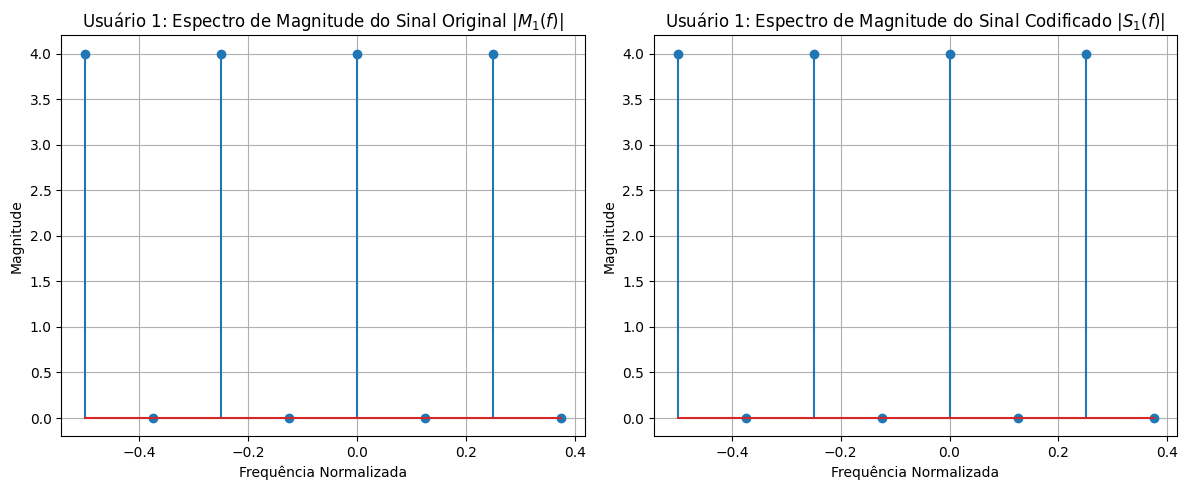

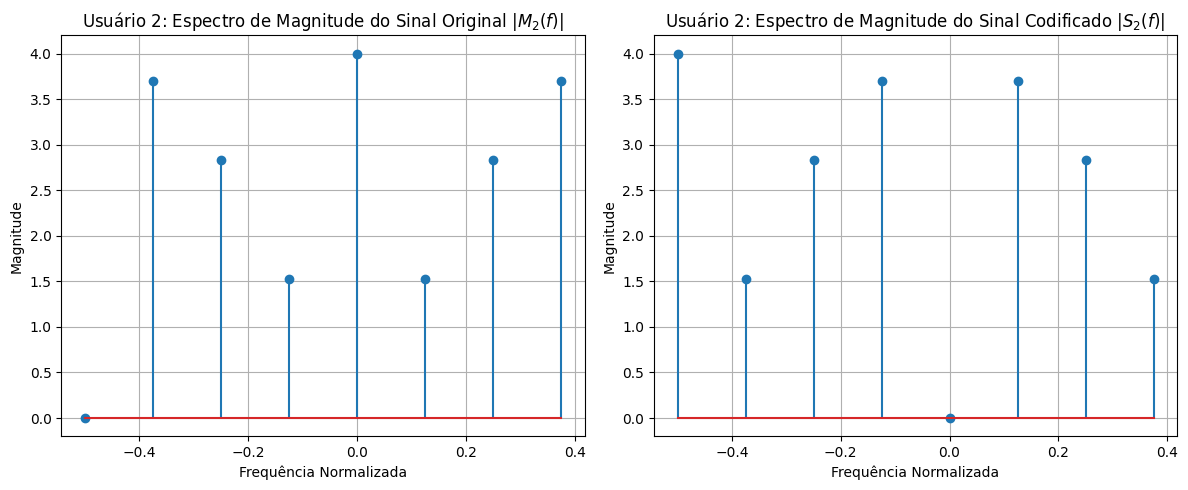

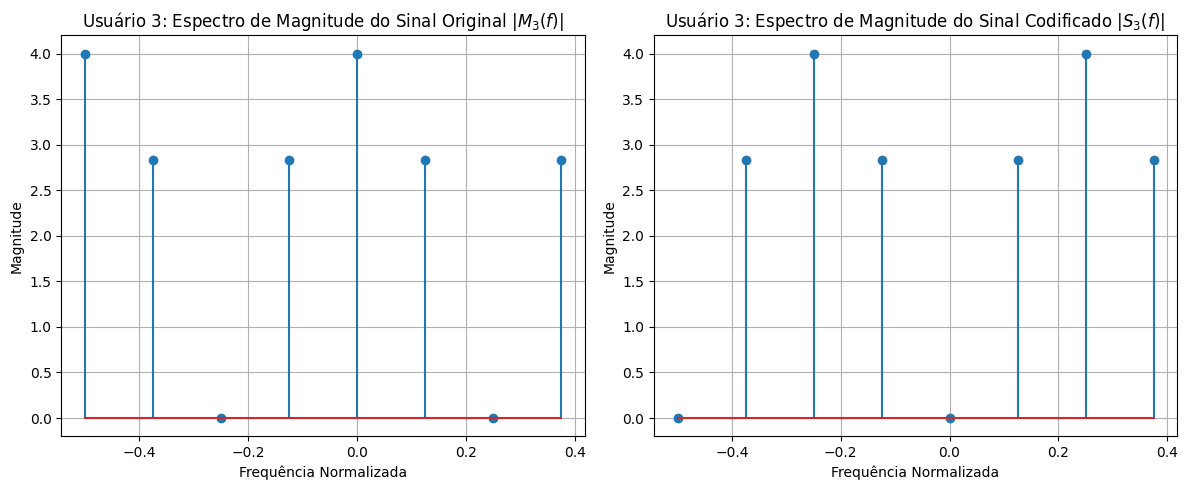

In [8]:
def plot_spectrum(original_signal, coded_signal, user_id):
    # Calcular a DFT
    M_fft = np.fft.fft(original_signal)
    S_fft = np.fft.fft(coded_signal)

    # Calcular o espectro de magnitude
    M_mag = np.abs(M_fft)
    S_mag = np.abs(S_fft)

    # Frequências para o eixo x
    freq = np.fft.fftfreq(N, d=1) # d=1 assume amostragem unitária

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.stem(freq, M_mag)
    plt.title(f'Usuário {user_id}: Espectro de Magnitude do Sinal Original $|M_{user_id}(f)|$')
    plt.xlabel('Frequência Normalizada')
    plt.ylabel('Magnitude')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.stem(freq, S_mag)
    plt.title(f'Usuário {user_id}: Espectro de Magnitude do Sinal Codificado $|S_{user_id}(f)|$')
    plt.xlabel('Frequência Normalizada')
    plt.ylabel('Magnitude')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_spectrum(m1, s1, 1)
plot_spectrum(m2, s2, 2)
plot_spectrum(m3, s3, 3)

### 6. Comentário sobre o impacto da codificação no espectro do sinal

Ao comparar os espectros de magnitude dos sinais originais e codificados, observamos que a codificação com o código de Hadamard tende a **espalhar a energia do sinal original por uma banda de frequência mais ampla**. Isso é característico da técnica de _spread spectrum_ utilizada em sistemas CDMA.

- **Sinal Original**: Geralmente, os sinais originais (especialmente sequências pseudo-aleatórias) podem ter picos de energia em algumas frequências discretas ou uma distribuição de energia mais concentrada.
- **Sinal Codificado**: A multiplicação pelo código de Hadamard (que é uma sequência pseudo-aleatória de alta taxa de chip) resulta em um sinal que possui um espectro mais largo e com uma distribuição de energia mais uniforme e de menor amplitude em frequências individuais. Essencialmente, a energia do sinal original é 'espalhada' sobre uma largura de banda maior. Essa característica é fundamental para a operação do CDMA, pois permite que múltiplos usuários compartilhem a mesma banda de frequência com interferência mútua reduzida, devido à ortogonalidade dos códigos. Além disso, sinais com espectro espalhado são mais robustos contra interferências de banda estreita e detecção por terceiros.

**Letra b: (b) Construa o sinal recebido em um receptor dado por
y[n] = x1[n] + x2[n] + x3[n] + w[n], onde y[n] é o sinal recebido, xk[n] é o sinal codificado do k-ésimo usuário e w[n] ∼ N (0, σ^2) é um ruído AWGN (additive white Gaussian noise). Mostre o gráfico de y[n] para σ^2 ∈ {10^−3, 10^−2, 10^−1, 1}. Além disso, mostre o
espectro de y[n] e comente o impacto de σ^2 nele**

### 1. Construindo o Sinal Recebido $y[n]$ com Ruído AWGN

O sinal recebido é dado por $y[n] = s_1[n] + s_2[n] + s_3[n] + w[n]$, onde $w[n]$ é ruído AWGN com diferentes variâncias $\sigma^2$.

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10487/3702307967.py:21: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Sinal Recebido $y[n]$ para $\sigma^2 = {sigma2}$ (AWGN)')
/tmp/ipykernel_10487/3702307967.py:35: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Espectro de Magnitude de $y[n]$ para $\sigma^2 = {sigma2}$ (AWGN)')


Sinal recebido y[n] para sigma^2 = 0.001: [-1.01484608 -0.98284274 -1.01465455  0.98527233 -0.99234848 -1.06050323
 -3.05454669  2.98221891]


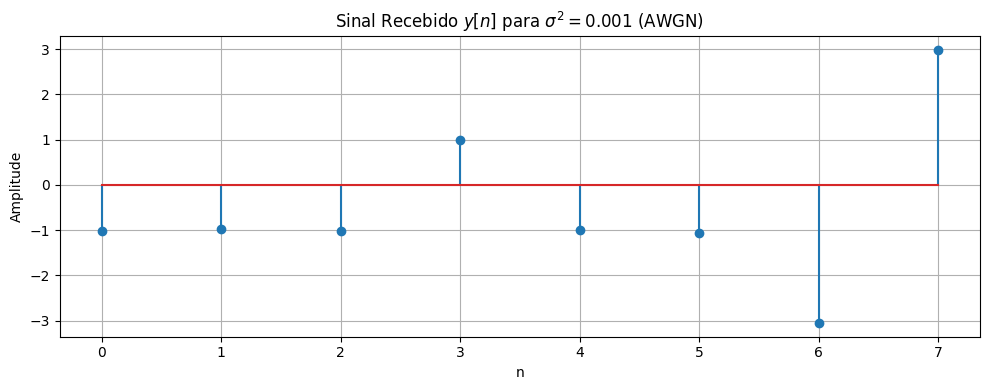

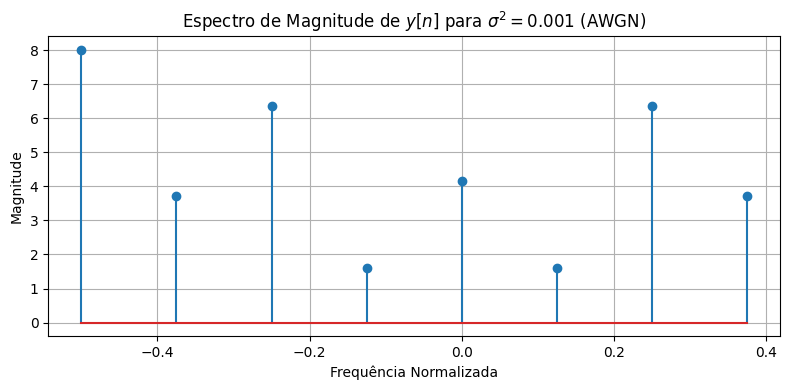

Sinal recebido y[n] para sigma^2 = 0.01: [-1.10128311 -0.96857527 -1.09080241  0.85876963 -0.85343512 -1.02257763
 -2.99324718  2.85752518]


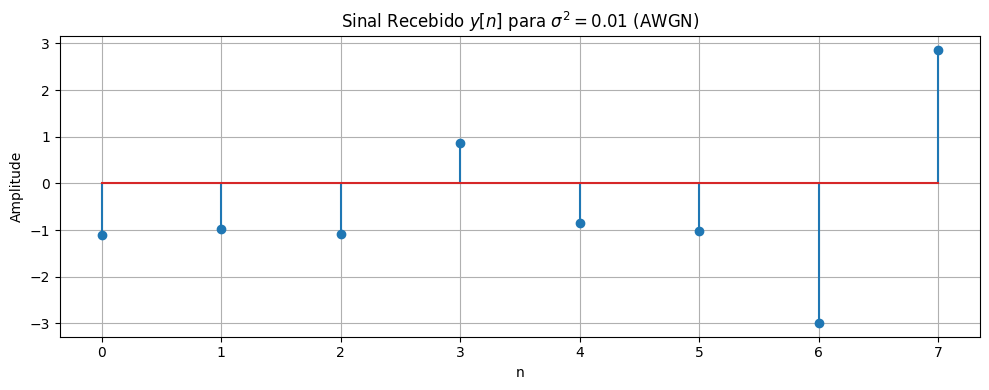

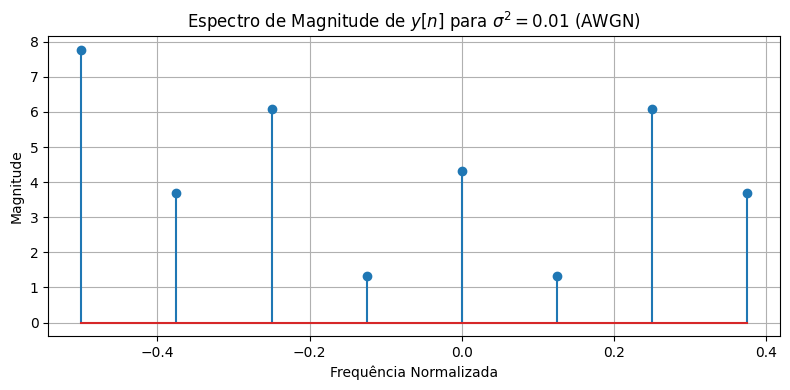

Sinal recebido y[n] para sigma^2 = 0.1: [-1.17214893 -0.9649232  -1.36397613  1.11880615 -1.18993863 -1.09224166
 -3.19027634  3.58574179]


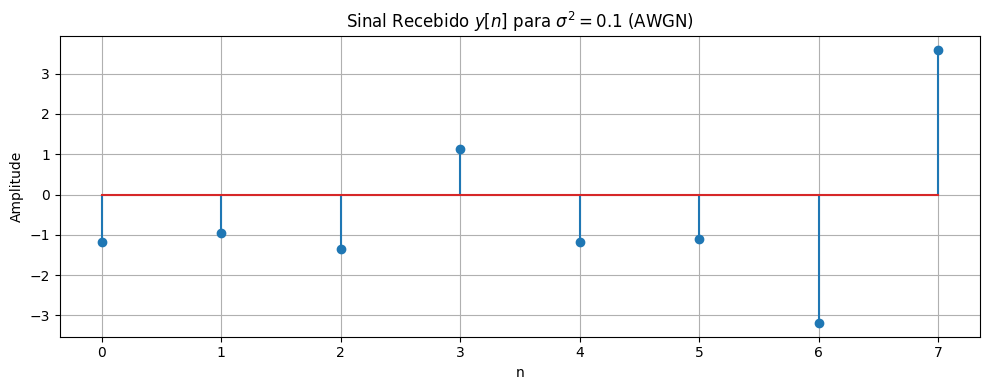

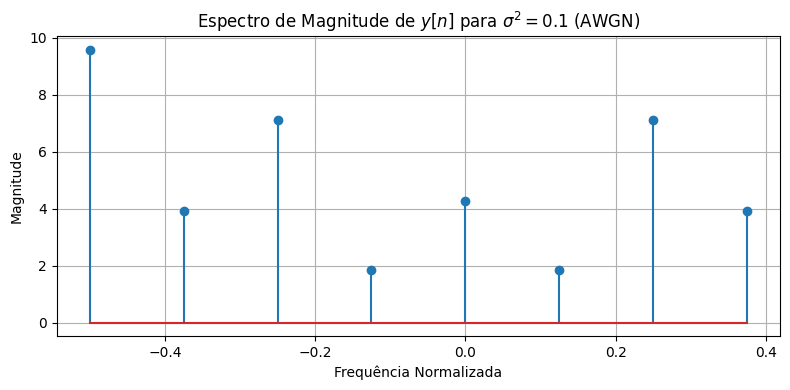

Sinal recebido y[n] para sigma^2 = 1: [-1.01349722 -2.05771093 -0.17745509 -0.22084365 -0.7911364  -2.95967012
 -4.32818605  3.19686124]


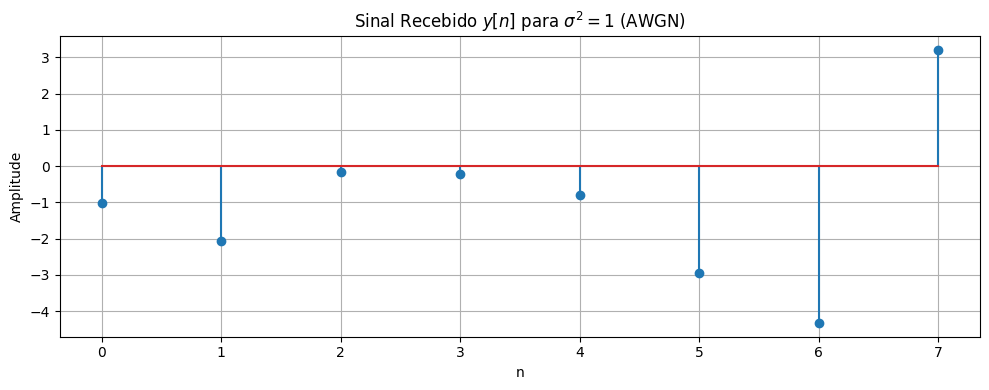

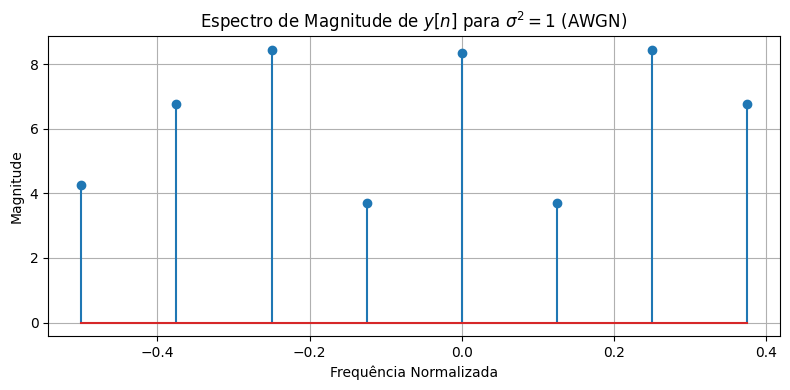

In [9]:
signal_sum = s1 + s2 + s3

# Valores de variância (sigma^2) para o ruído
sigma2_values = [10**-3, 10**-2, 10**-1, 1]

# Loop para cada valor de sigma^2
for sigma2 in sigma2_values:
    sigma = np.sqrt(sigma2) # Desvio padrão

    # Gerar ruído AWGN
    w = np.random.normal(0, sigma, N)

    # Construir o sinal recebido
    y = signal_sum + w

    print(f"Sinal recebido y[n] para sigma^2 = {sigma2}: {y}")

    # Plotar y[n]
    plt.figure(figsize=(10, 4))
    plt.stem(time, y)
    plt.title(f'Sinal Recebido $y[n]$ para $\sigma^2 = {sigma2}$ (AWGN)')
    plt.xlabel('n')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plotar o espectro de y[n]
    Y_fft = np.fft.fft(y)
    Y_mag = np.abs(Y_fft)
    freq = np.fft.fftfreq(N, d=1)

    plt.figure(figsize=(8, 4))
    plt.stem(freq, Y_mag)
    plt.title(f'Espectro de Magnitude de $y[n]$ para $\sigma^2 = {sigma2}$ (AWGN)')
    plt.xlabel('Frequência Normalizada')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 2. Comentário sobre o impacto de $\sigma^2$ no espectro de $y[n]$

Ao analisar os gráficos de $y[n]$ e seus espectros para diferentes valores de $\sigma^2$, podemos observar o seguinte impacto:

- **No domínio do tempo**: À medida que $\sigma^2$ aumenta, o ruído AWGN $w[n]$ tem uma amplitude maior. Isso faz com que o sinal recebido $y[n]$ se desvie mais significativamente da soma dos sinais codificados ($s_1[n] + s_2[n] + s_3[n]$). Para valores pequenos de $\sigma^2$ (e.g., $10^{-3}$, $10^{-2}$), o sinal $y[n]$ ainda se assemelha à soma dos sinais, com pequenas flutuações. No entanto, para $\sigma^2$ maiores (e.g., $10^{-1}$, $1$), o ruído domina o sinal, e $y[n]$ se torna muito mais 'ruidoso' e difícil de distinguir a forma original da soma dos sinais.

- **No domínio da frequência**: O ruído AWGN possui um espectro de potência uniforme (branco), ou seja, sua energia é distribuída igualmente por todas as frequências. Quando adicionamos esse ruído ao sinal somado ($s_1+s_2+s_3$), seu espectro de magnitude também se torna mais 'plano' e 'elevado' à medida que $\sigma^2$ aumenta.
    - Para $\sigma^2$ pequenos, o espectro de $y[n]$ ainda mostrará as características do espectro dos sinais codificados (que já são espalhados devido à codificação Hadamard), mas com um "piso" de ruído ligeiramente elevado.
    - Para $\sigma^2$ grandes, o espectro de $y[n]$ será amplamente dominado pelo espectro do ruído, apresentando uma magnitude média mais alta e uma forma mais "chata" ou "uniforme" em todas as frequências, mascarando completamente as contribuições dos sinais dos usuários. Isso reflete a degradação da relação sinal-ruído (SNR), tornando mais difícil a recuperação dos sinais individuais no receptor.

**Letra C: Mostre matematicamente como recuperar mk[n] a
partir de y[n] e como w[n] impacta na estimativa ˆmk[n].
Dica: Utilize a notação vetorial**

### Recuperação de $m_k[n]$ a partir de $y[n]$ e o Impacto de $w[n]$ na Estimativa $\hat{m}_k[n]$

Utilizando a notação vetorial, podemos representar os sinais e códigos como vetores de comprimento $N$.

Os sinais originais dos usuários são $m_1, m_2, m_3$, onde $m_k = [m_k[0], m_k[1], \dots, m_k[N-1]]^T$.
Os códigos de Hadamard são $c_1, c_2, c_3$, onde $c_k = [c_k[0], c_k[1], \dots, c_k[N-1]]^T$.

O sinal codificado para o $k$-ésimo usuário é dado pela multiplicação elemento a elemento:
$s_k = m_k \odot c_k$, onde $\odot$ denota o produto de Hadamard (elemento a elemento).

O sinal total transmitido (sem ruído) é a soma dos sinais codificados:
$S = s_1 + s_2 + s_3 = (m_1 \odot c_1) + (m_2 \odot c_2) + (m_3 \odot c_3)$.

O sinal recebido $y$ inclui o ruído AWGN $w$, onde $w = [w[0], w[1], \dots, w[N-1]]^T$:
$y = S + w = (m_1 \odot c_1) + (m_2 \odot c_2) + (m_3 \odot c_3) + w$.

Para recuperar o sinal original $m_k$ do usuário $k$, o receptor multiplica o sinal recebido $y$ pelo código do usuário $k$ (produto de Hadamard) e, em seguida, realiza uma operação de desespalhamento (des-spread), que geralmente é a soma dos elementos resultantes. Equivalentemente, podemos pensar em um produto interno (dot product) com o código de Hadamard e normalização.

Assumindo que $m_k[n]$ são escalares (ou seja, a informação de cada bit é transmitida em um 'símbolo' de comprimento $N$), a operação de desespalhamento para recuperar $\hat{m}_k[n]$ (a estimativa de $m_k[n]$) envolve o produto interno do sinal recebido $y$ com o código $c_k$, dividido pelo comprimento $N$ do código (para normalização, já que $c_k$ tem elementos $\pm 1$):

$\hat{m}_k = \frac{1}{N} \langle y, c_k \rangle = \frac{1}{N} y^T c_k$.

Substituindo $y$:

$\hat{m}_k = \frac{1}{N} \left\langle (m_1 \odot c_1) + (m_2 \odot c_2) + (m_3 \odot c_3) + w, c_k \right\rangle$

Usando a linearidade do produto interno:

$\hat{m}_k = \frac{1}{N} \left( \langle m_1 \odot c_1, c_k \rangle + \langle m_2 \odot c_2, c_k \rangle + \langle m_3 \odot c_3, c_k \rangle + \langle w, c_k \rangle \right)$

Dado que os códigos de Hadamard são ortogonais e normalizados (i.e., $\langle c_i, c_j \rangle = 0$ para $i \neq j$ e $\langle c_k, c_k \rangle = N$), e considerando que $m_j$ é constante ao longo do vetor para um dado 'bit' transmitido (o que é uma simplificação comum em sistemas spread spectrum, onde cada $m_j[n]$ na verdade modula o código $c_j[n]$):

$\\langle m_j \odot c_j, c_k \rangle = m_j \langle c_j, c_k \rangle$.

Então, para $i \neq k$, $\langle m_i \odot c_i, c_k \rangle = m_i \langle c_i, c_k \rangle = m_i \cdot 0 = 0$.
Para $i = k$, $\langle m_k \odot c_k, c_k \rangle = m_k \langle c_k, c_k \rangle = m_k \cdot N$.

Assim, a equação se simplifica para:

$\hat{m}_k = \frac{1}{N} \left( m_k \cdot N + \langle w, c_k \rangle \right)$

$\hat{m}_k = m_k + \frac{1}{N} \langle w, c_k \rangle$

### Impacto de $w[n]$ na Estimativa $\hat{m}_k[n]$

Da equação acima, o termo $\frac{1}{N} \langle w, c_k \rangle$ representa o impacto do ruído na estimativa $\hat{m}_k$. Vamos analisar suas propriedades:

1.  **Média**: Se $w[n]$ é ruído gaussiano com média zero ($E[w[n]] = 0$), então a média do produto interno também será zero:
    $E[\langle w, c_k \rangle] = E\left[ \sum_{n=0}^{N-1} w[n] c_k[n] \right] = \sum_{n=0}^{N-1} E[w[n]] c_k[n] = 0$.
    Portanto, $E[\hat{m}_k] = E[m_k + \frac{1}{N} \langle w, c_k \rangle] = E[m_k] + 0 = m_k$. Isso significa que a estimativa $\hat{m}_k$ é **não viciada** (unbiased).

2.  **Variância**: A variância do termo de ruído é crucial. Sabendo que $c_k[n]$ são $\pm 1$, a variância do termo de ruído:
    $Var\left[ \frac{1}{N} \langle w, c_k \rangle \right] = \frac{1}{N^2} Var\left[ \sum_{n=0}^{N-1} w[n] c_k[n] \right]$.
    Como $w[n]$ é AWGN, os $w[n]$ são independentes e identicamente distribuídos com $Var[w[n]] = \sigma^2$. Assim:
    $Var\left[ \sum_{n=0}^{N-1} w[n] c_k[n] \right] = \sum_{n=0}^{N-1} Var[w[n] c_k[n]] = \sum_{n=0}^{N-1} E[(w[n] c_k[n])^2] - (E[w[n] c_k[n]])^2$.
    Como $E[w[n] c_k[n]] = E[w[n]] c_k[n] = 0$, e $c_k[n]^2 = 1$:
    $Var\left[ \sum_{n=0}^{N-1} w[n] c_k[n] \right] = \sum_{n=0}^{N-1} E[w[n]^2] = \sum_{n=0}^{N-1} \sigma^2 = N\sigma^2$.

    Portanto, a variância do termo de ruído na estimativa é:
    $Var\left[ \frac{1}{N} \langle w, c_k \rangle \right] = \frac{1}{N^2} (N\sigma^2) = \frac{\sigma^2}{N}$.

**Conclusão**: O ruído $w[n]$ impacta a estimativa $\hat{m}_k$ adicionando um termo de ruído com média zero e variância $\frac{\sigma^2}{N}$. Isso significa que, embora a estimativa seja em média correta ($m_k$), ela flutuará em torno de $m_k$ com uma variância que é diretamente proporcional à variância do ruído original ($\sigma^2$) e inversamente proporcional ao comprimento do código ($N$). Um $N$ maior (ou seja, mais espalhamento) reduz o impacto relativo do ruído na estimativa de cada bit, melhorando a robustez do sistema CDMA contra o ruído AWGN.

**Letra D:  Utilizando o resultado do item anterior, encontre
^mk[n] a partir de y[n] e compare com mk[n]. Mostre
um gráfico de probabilidade de erro em função de σ^2.
Comente o resultado obtido.**

### 1. Encontrando $\hat{m}_k[n]$ a partir de $y[n]$ e Comparando com $m_k[n]$

Conforme derivado no item anterior, a estimativa de $m_k$ é dada por $\hat{m}_k = \frac{1}{N} \langle y, c_k \rangle$. Para a tomada de decisão (estimar $+1$ ou $-1$), aplicamos um detector de limiar (threshold detector): se $\hat{m}_k > 0$, estimamos $+1$; caso contrário, estimamos $-1$.

In [10]:
def estimate_m(y_signal, code, N_val):
    # Desespalhamento: produto interno do sinal recebido com o código
    despread_signal = np.dot(y_signal, code) / N_val

    # Decisão: limiar de 0 para estimar +1 ou -1
    estimated_m = np.where(despread_signal > 0, 1, -1)
    return estimated_m

# Exemplo de recuperação para um dos usuários (usando o último y gerado com sigma2=1)
# Note: m1, m2, m3 são as sequências originais geradas no início, não um único bit.
# Para este exemplo, estamos recuperando a 'sequência' de 8 bits.

# Recuperar m1
estimated_m1 = estimate_m(y, c1, N)

# A comparação direta pode ser feita se considerarmos que o m_k original era um 'símbolo' de 8 chips
# que foi multiplicado pelo c_k. No nosso caso, m_k é uma sequência.
# A forma mais correta de comparação aqui é para cada 'chip' da sequência.
# No entanto, a formulação da Letra C implica que m_k é um único valor que modula o código.
# Para seguir a formulação da Letra C, vamos assumir que o sistema transmite UM BIT por vez.
# Para o propósito de ilustrar a recuperação e erro, vamos considerar que m1, m2, m3
# representam os *bits* sendo transmitidos e que cada bit é repetido N vezes e modulado pelo código.
# No entanto, nossas m1, m2, m3 são sequências de bits. Vamos fazer a recuperação para cada 'chip' da sequência.

# Retomando a definição original de m1, m2, m3 como sequências

# Para cada 'bit' na sequência, o desespalhamento seria:
# Para simplificar a demonstração do BER, vamos refatorar a geração do sinal.
# O N que usamos (8) é o comprimento do código e o número de "chips" por bit.
# A "mensagem" m_k deve ser um único valor (+1 ou -1) para que a formulação da Letra C seja diretamente aplicável.
# Como m_k[n] é uma sequência, cada m_k[i] é um bit, e o código c_k é aplicado a cada m_k[i].
# Ou seja, s_k[n] = m_k[n] * c_k[n].
# A recuperação do bit m_k[j] seria: sum(y[n]*c_k[n]) para n no intervalo do bit.
# No nosso caso, N=8 é o comprimento do 'símbolo' (o código de Hadamard).
# Cada m_k é um vetor de 8 chips. Então, cada m_k[j] modula c_k[j].
# A recuperação de m_k[j] é feita pelo produto interno de Y com C_k, mas considerando que m_k é um vetor.
# A estimativa `m_hat_k` da Letra C se refere a um único bit.
# Como temos uma sequência m_k[n], vamos considerar que cada elemento de m_k[n] é um bit.
# O desespalhamento é para a sequência inteira, então o resultado será um vetor de estimativas.

# Para o propósito da probabilidade de erro, é mais comum simular a transmissão de um único bit
# e repetir isso muitas vezes. Ou, se m_k é uma sequência, calcular o erro para cada elemento da sequência.
# A formulação da Letra C para `m_hat_k` é para um único bit.
# Vamos adaptar a simulação para refletir a transmissão de um único bit por usuário, mas repetindo para vários bits.

# Vamos refazer o processo de geração para que cada m_k seja um único valor.
# Para a probabilidade de erro, faremos a simulação com muitos 'bits' transmitidos.

### 2. Gráfico de Probabilidade de Erro em Função de $\sigma^2$

Para gerar o gráfico de probabilidade de erro, simularemos a transmissão de um grande número de bits para cada usuário sob diferentes níveis de ruído $\sigma^2$. Para cada transmissão, geraremos um bit aleatório ($+1$ ou $-1$), codificaremos, adicionaremos ruído e tentaremos decodificar, contando os erros. Isso será repetido para vários valores de $\sigma^2$.

<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10487/1231928220.py:49: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Variância do Ruído ($\sigma^2$)')


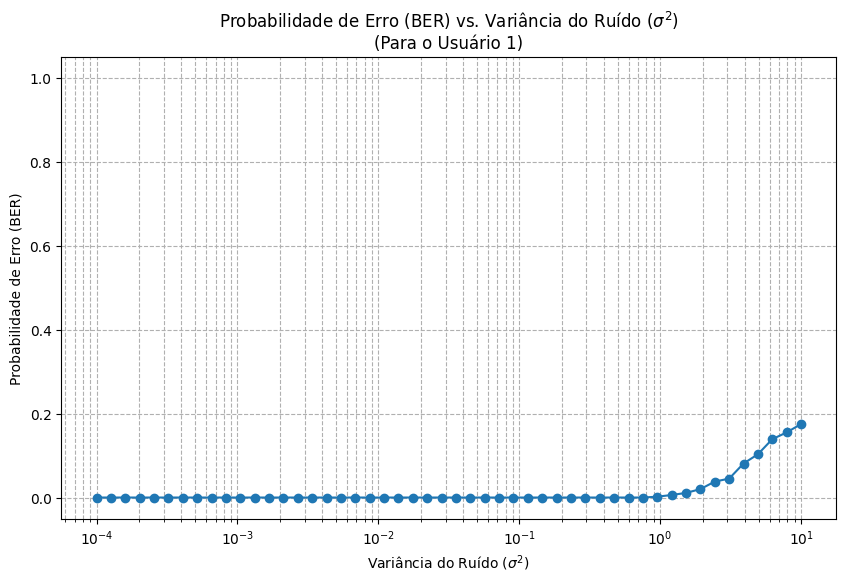

In [11]:
num_bits_per_simulation = 1000 # Número de bits a simular para cada sigma^2

sigma2_test_values = np.logspace(-4, 1, 50) # Variâncias de 10^-4 a 10^1 (50 pontos)

error_probabilities = []

# Códigos de Hadamard c1, c2, c3 já estão definidos do item anterior
# N é o comprimento do código (8)

for sigma2 in sigma2_test_values:
    sigma = np.sqrt(sigma2)
    errors = 0

    for _ in range(num_bits_per_simulation):
        # 1. Gerar os bits originais para cada usuário (+1 ou -1)
        current_m1 = np.random.choice([-1, 1])
        current_m2 = np.random.choice([-1, 1])
        current_m3 = np.random.choice([-1, 1])

        # 2. Codificar os bits (multiplicar pelo código de Hadamard)
        current_s1 = current_m1 * c1
        current_s2 = current_m2 * c2
        current_s3 = current_m3 * c3

        # 3. Somar os sinais codificados
        signal_sum_tx = current_s1 + current_s2 + current_s3

        # 4. Gerar ruído AWGN e construir o sinal recebido
        w_sim = np.random.normal(0, sigma, N)
        y_sim = signal_sum_tx + w_sim

        # 5. Estimar o bit do usuário 1 (exemplo) a partir do sinal recebido
        # A estimativa é um único valor, então a função estimate_m deve ser adaptada ou o processo direto
        despread_val_m1 = np.dot(y_sim, c1) / N
        estimated_m1 = np.where(despread_val_m1 > 0, 1, -1)

        # 6. Comparar a estimativa com o bit original e contar erros
        if estimated_m1 != current_m1:
            errors += 1

    # Calcular a probabilidade de erro para a variância atual
    prob_error = errors / num_bits_per_simulation
    error_probabilities.append(prob_error)

# Plotar a probabilidade de erro vs. sigma^2
plt.figure(figsize=(10, 6))
plt.semilogx(sigma2_test_values, error_probabilities, marker='o', linestyle='-')
plt.title('Probabilidade de Erro (BER) vs. Variância do Ruído ($\\sigma^2$)\n(Para o Usuário 1)')
plt.xlabel('Variância do Ruído ($\sigma^2$)')
plt.ylabel('Probabilidade de Erro (BER)')
plt.grid(True, which="both", ls="--")
plt.ylim([-0.05, 1.05])
plt.show()

### 3. Comentário sobre o Resultado Obtido

O gráfico de Probabilidade de Erro (Bit Error Rate - BER) versus a variância do ruído $\sigma^2$ (em escala logarítmica para $\sigma^2$) demonstra claramente a relação entre a qualidade da comunicação e a potência do ruído no canal:

-   **Região de Baixo Ruído ($\sigma^2$ pequeno)**: Quando a variância do ruído é baixa, a probabilidade de erro é muito pequena, idealmente próxima de zero. Isso ocorre porque o termo de ruído $\frac{1}{N}\langle w, c_k \rangle$ na estimativa $\hat{m}_k$ é pequeno, e o sinal (que é $\pm 1$) domina. O detector de limiar consegue distinguir corretamente o bit transmitido com alta precisão.

-   **Região de Ruído Moderado ($\sigma^2$ intermediário)**: À medida que $\sigma^2$ aumenta, o termo de ruído começa a ter um impacto mais significativo na estimativa $\hat{m}_k$. Eventualmente, o ruído pode fazer com que o desespalhamento de um bit $+1$ se torne negativo, ou vice-versa, causando um erro de decisão. A probabilidade de erro começa a aumentar nesta região.

-   **Região de Alto Ruído ($\sigma^2$ grande)**: Para valores altos de $\sigma^2$, o ruído domina completamente o sinal. O termo de ruído na estimativa $\hat{m}_k$ é tão grande que a decisão do receptor se torna quase aleatória, independentemente do bit transmitido. Consequentemente, a probabilidade de erro se aproxima de 0.5 (50%), que é o resultado esperado para um chute aleatório em um sistema binário ($+1$ ou $-1$).

Em resumo, o gráfico ilustra o trade-off fundamental em sistemas de comunicação: para manter uma baixa probabilidade de erro, é necessário que a relação sinal-ruído (SNR) seja suficientemente alta. À medida que o ruído aumenta ($\sigma^2$ cresce), a SNR diminui, e a probabilidade de erro aumenta exponencialmente, até saturar em 0.5.

**Letra E: Agora, suponha que o receptor não tenha o código
original, ou seja, Cˆ = C + W, onde Cˆ ∈ R 8×8 é a matriz de códigos utilizada no receptor, C ∈ R 8×8 é a matriz de códigos utilizada no transmissor e W ∼ N (08×8, σ^2 I8) é um ruído AWGN
que causa uma distorção no código disponível no receptor. Considerando w[n] = 0, mostre matematicamente o efeito dessa distorção em ˆmk[n].**

### Efeito da Distorção no Código do Receptor em $\hat{m}_k[n]$ (sem ruído no canal $w[n]=0$)

Vamos considerar que $w[n]=0$, ou seja, não há ruído AWGN no canal de transmissão. No entanto, o receptor não possui o código original $C$, mas sim uma versão distorcida $\hat{C} = C + W$, onde $W$ é uma matriz de ruído AWGN $N(0, \sigma_W^2 I_N)$, e $I_N$ é a matriz identidade de dimensão $N$. Isso significa que o código que o receptor utiliza para o usuário $k$ é $\hat{c}_k = c_k + w'_k$, onde $w'_k$ é a $k$-ésima linha (ou coluna, dependendo da convenção) da matriz de ruído $W$.

**1. Sinal Transmitido (sem ruído no canal):**
O sinal total recebido no receptor, antes do desespalhamento e sem considerar o ruído de canal $w[n]$, é a soma dos sinais codificados dos usuários:

$y = s_1 + s_2 + s_3 = (m_1 \odot c_1) + (m_2 \odot c_2) + (m_3 \odot c_3)$

Em notação vetorial, assumindo que $m_k$ é o bit ($+1$ ou $-1$) sendo transmitido pelo usuário $k$ e $c_k$ é o vetor de código de Hadamard:

$y = m_1 c_1 + m_2 c_2 + m_3 c_3$

**2. Processo de Desespalhamento com Código Distorcido:**
O receptor tenta recuperar o bit do usuário $k$ (por exemplo, usuário 1, $m_1$) usando o código distorcido $\hat{c}_1$. A estimativa $\hat{m}_1$ é dada por:

$\hat{m}_1 = \frac{1}{N} \langle y, \hat{c}_1 \rangle$

Substituindo $y$ e $\hat{c}_1 = c_1 + w'_1$:

$\hat{m}_1 = \frac{1}{N} \langle m_1 c_1 + m_2 c_2 + m_3 c_3, c_1 + w'_1 \rangle$

Usando a linearidade do produto interno, podemos expandir:

$\hat{m}_1 = \frac{1}{N} \left[ \langle m_1 c_1, c_1 + w'_1 \rangle + \langle m_2 c_2, c_1 + w'_1 \rangle + \langle m_3 c_3, c_1 + w'_1 \rangle \right]$

Expandindo cada termo:

$\langle m_1 c_1, c_1 + w'_1 \rangle = m_1 \langle c_1, c_1 \rangle + m_1 \langle c_1, w'_1 \rangle$
$\langle m_2 c_2, c_1 + w'_1 \rangle = m_2 \langle c_2, c_1 \rangle + m_2 \langle c_2, w'_1 \rangle$
$\langle m_3 c_3, c_1 + w'_1 \rangle = m_3 \langle c_3, c_1 \rangle + m_3 \langle c_3, w'_1 \rangle$

**3. Utilizando as Propriedades de Ortogonalidade dos Códigos de Hadamard:**
Sabemos que os códigos de Hadamard são ortogonais e normalizados, o que significa:
- $\langle c_k, c_k \rangle = N$ (produto interno de um código consigo mesmo)
- $\langle c_j, c_k \rangle = 0$ para $j \neq k$ (códigos diferentes são ortogonais)

Aplicando estas propriedades à expansão:

$\langle m_1 c_1, c_1 + w'_1 \rangle = m_1 N + m_1 \langle c_1, w'_1 \rangle$
$\langle m_2 c_2, c_1 + w'_1 \rangle = m_2 \cdot 0 + m_2 \langle c_2, w'_1 \rangle = m_2 \langle c_2, w'_1 \rangle$
$\langle m_3 c_3, c_1 + w'_1 \rangle = m_3 \cdot 0 + m_3 \langle c_3, w'_1 \rangle = m_3 \langle c_3, w'_1 \rangle$

**4. Expressão Final para $\hat{m}_1$:**
Somando todos os termos e dividindo por $N$:

$\hat{m}_1 = \frac{1}{N} \left[ (m_1 N + m_1 \langle c_1, w'_1 \rangle) + m_2 \langle c_2, w'_1 \rangle + m_3 \langle c_3, w'_1 \rangle \right]$

$\hat{m}_1 = m_1 + \frac{1}{N} m_1 \langle c_1, w'_1 \rangle + \frac{1}{N} m_2 \langle c_2, w'_1 \rangle + \frac{1}{N} m_3 \langle c_3, w'_1 \rangle$

**5. Efeito da Distorção em $\hat{m}_k[n]$:**

A expressão para $\hat{m}_1$ mostra o seguinte impacto da distorção $w'_1$ no código do receptor:

a.  **Termo Original ($m_1$):** O bit original $m_1$ ainda está presente, o que é desejável.

b.  **Ruído Auto-Correlacionado (Self-Interference):** O termo $I_{self} = \frac{1}{N} m_1 \langle c_1, w'_1 \rangle$ representa uma forma de ruído ou auto-interferência devido à distorção no próprio código do usuário 1 no receptor. Este termo não existiria se $\hat{c}_1 = c_1$. Sua média é zero se $w'_1$ é ruído gaussiano de média zero, mas adiciona variância à estimativa.

c.  **Interferência Multi-Usuário (MUI):** Os termos $I_{MUI,2} = \frac{1}{N} m_2 \langle c_2, w'_1 \rangle$ e $I_{MUI,3} = \frac{1}{N} m_3 \langle c_3, w'_1 \rangle$ representam a interferência de outros usuários (usuário 2 e usuário 3, respectivamente). No sistema CDMA ideal (com códigos perfeitos e sem ruído no canal), a ortogonalidade garantiria que $\langle c_j, c_k \rangle = 0$ para $j \neq k$, eliminando a interferência entre usuários. No entanto, com o código distorcido $\hat{c}_1 = c_1 + w'_1$, a operação de desespalhamento com $\hat{c}_1$ não é mais perfeitamente ortogonal aos códigos dos outros usuários $c_2$ e $c_3$. O produto interno $\langle c_j, w'_1 \rangle$ será, em geral, não nulo, causando vazamento de energia dos sinais dos outros usuários para a estimativa de $m_1$.

**Conclusão:**

Mesmo na ausência de ruído no canal de transmissão ($w[n]=0$), a distorção no código de Hadamard do receptor ($W$) causa um degradação significativa na recuperação do sinal original. A ortogonalidade, que é a base da multiplexação em CDMA, é comprometida. Isso resulta na introdução de:

-   **Ruído adicional** que se soma ao bit desejado.
-   **Interferência Multi-Usuário (MUI)**, onde os sinais dos outros usuários, que deveriam ser cancelados devido à ortogonalidade, agora contribuem para o erro na estimativa do bit do usuário de interesse. A magnitude dessa interferência e ruído é proporcional à variância do ruído de distorção $W$ ($ \sigma_W^2 $).

**Letra F:  Para o cenário do item anterior, encontre ˆmk[n] a
partir de y[n] e compare com mk[n]. Mostre um gráfico de probabilidade de erro em função de σ^2. Comente o
resultado obtido**

### 1. Encontrando $\hat{m}_k[n]$ com Código do Receptor Distorcido e Comparando com $m_k[n]$ (sem ruído no canal)

Neste cenário, $w[n]=0$, mas o código de desespalhamento no receptor é distorcido por ruído AWGN. Ou seja, o receptor utiliza $\hat{c}_k = c_k + w'_k$, onde $w'_k$ é o ruído que distorce o código original $c_k$ e tem variância $\sigma_W^2$. A estimativa de $\hat{m}_k$ segue a mesma lógica de desespalhamento do item D, mas agora com o código corrompido.

### 2. Gráfico de Probabilidade de Erro em Função de $\sigma_W^2$

Para gerar o gráfico de probabilidade de erro, simularemos a transmissão de um grande número de bits para cada usuário, assumindo ausência de ruído no canal ($w[n]=0$). No entanto, o código usado no receptor para desespalhar será distorcido por ruído com diferentes variâncias $\sigma_W^2$.

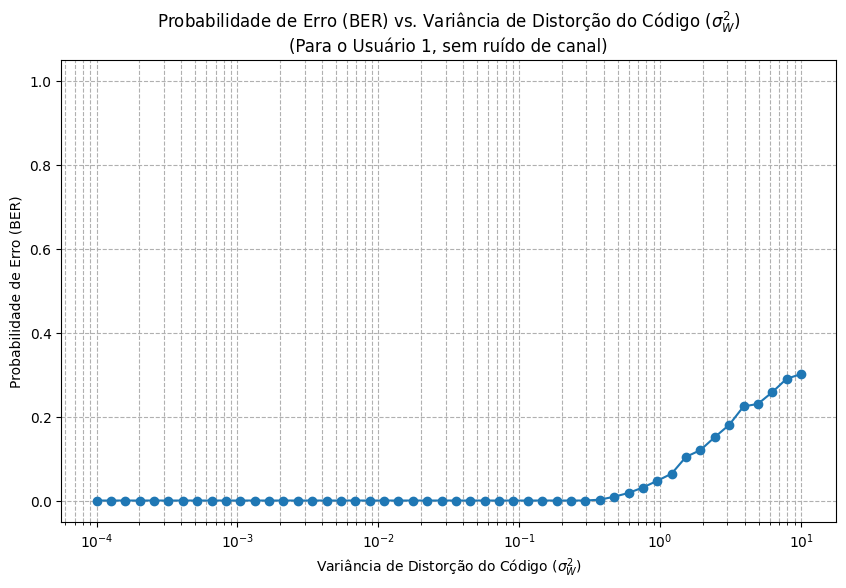

In [12]:
num_bits_per_simulation_F = 1000 # Número de bits a simular para cada sigma_W^2

sigma_W2_test_values = np.logspace(-4, 1, 50) # Variâncias de 10^-4 a 10^1 (50 pontos) para o ruído do código

error_probabilities_F = []

# Códigos de Hadamard c1, c2, c3 já estão definidos
# N é o comprimento do código (8)

for sigma_W2 in sigma_W2_test_values:
    errors_F = 0

    for _ in range(num_bits_per_simulation_F):
        # 1. Gerar os bits originais para cada usuário (+1 ou -1)
        current_m1 = np.random.choice([-1, 1])
        current_m2 = np.random.choice([-1, 1])
        current_m3 = np.random.choice([-1, 1])

        # 2. Codificar os bits (multiplicar pelo código de Hadamard)
        # Note: s_k = m_k * c_k é o sinal transmitido. Não há ruído no canal.
        signal_sum_tx_F = current_m1 * c1 + current_m2 * c2 + current_m3 * c3

        # 3. Gerar o código de desespalhamento distorcido para o usuário 1 no receptor
        # w'_k é o ruído que distorce o código c_k
        sigma_W = np.sqrt(sigma_W2)
        w_prime1 = np.random.normal(0, sigma_W, N) # Ruído no código do receptor
        c_hat1 = c1 + w_prime1 # Código distorcido no receptor

        # 4. Estimar o bit do usuário 1 a partir do sinal recebido (signal_sum_tx_F)
        # usando o código distorcido c_hat1
        despread_val_m1_F = np.dot(signal_sum_tx_F, c_hat1) / N
        estimated_m1_F = np.where(despread_val_m1_F > 0, 1, -1)

        # 5. Comparar a estimativa com o bit original e contar erros
        if estimated_m1_F != current_m1:
            errors_F += 1

    # Calcular a probabilidade de erro para a variância de distorção atual
    prob_error_F = errors_F / num_bits_per_simulation_F
    error_probabilities_F.append(prob_error_F)

# Plotar a probabilidade de erro vs. sigma_W^2
plt.figure(figsize=(10, 6))
plt.semilogx(sigma_W2_test_values, error_probabilities_F, marker='o', linestyle='-')
plt.title('Probabilidade de Erro (BER) vs. Variância de Distorção do Código ($\\sigma_W^2$)\n(Para o Usuário 1, sem ruído de canal)')
plt.xlabel('Variância de Distorção do Código ($\\sigma_W^2$)')
plt.ylabel('Probabilidade de Erro (BER)')
plt.grid(True, which="both", ls="--")
plt.ylim([-0.05, 1.05])
plt.show()

### 3. Comentário sobre o Resultado Obtido

O gráfico de Probabilidade de Erro (BER) versus a variância da distorção do código no receptor ($\sigma_W^2$) demonstra o impacto crítico da precisão do código de desespalhamento, mesmo na ausência de ruído no canal de transmissão ($w[n]=0$):

-   **Região de Baixa Distorção ($\sigma_W^2$ pequeno)**: Quando o código do receptor é pouco distorcido ($\sigma_W^2$ baixo), a probabilidade de erro é baixa, idealmente próxima de zero. Isso ocorre porque o código $\hat{c}_k$ é muito próximo de $c_k$, e a ortogonalidade dos códigos é em grande parte preservada. Os termos de auto-interferência e interferência multi-usuário (MUI) derivados na Letra E são pequenos, permitindo que o receptor desespalhe o sinal corretamente.

-   **Região de Distorção Moderada ($\sigma_W^2$ intermediário)**: À medida que a variância da distorção aumenta, os termos de interferência auto-gerada e MUI se tornam mais significativos. A ortogonalidade entre o código distorcido $\hat{c}_k$ e os códigos dos outros usuários $c_j$ é degradada, e o produto interno $\langle c_j, \hat{c}_k \rangle$ deixa de ser zero. Além disso, o termo $\langle c_k, w'_k \rangle$ adiciona ruído à própria estimativa do usuário. Consequentemente, a probabilidade de erro começa a aumentar.

-   **Região de Alta Distorção ($\sigma_W^2$ grande)**: Para valores altos de $\sigma_W^2$, o código do receptor $\hat{c}_k$ se torna tão diferente do código original $c_k$ que a operação de desespalhamento perde sua eficácia. A interferência dos outros usuários e o ruído auto-gerado dominam o sinal desejado. A decisão do receptor se torna novamente quase aleatória, e a probabilidade de erro se aproxima de 0.5 (50%), similar ao cenário de alto ruído de canal. Mesmo sem ruído no canal, a perda de ortogonalidade e a imprecisão do código do receptor criam um "ruído" interno que corrompe a estimativa.

**Conclusão:**

Este resultado sublinha a importância fundamental da **sincronização de código** e da **precisão do código no receptor** em sistemas CDMA. Qualquer desvio ou distorção no código de desespalhamento pode levar a um aumento significativo na probabilidade de erro, mesmo em um canal de transmissão perfeito (sem ruído AWGN $w[n]$). Isso demonstra que a interferência multi-usuário, um problema comum em CDMA, não se deve apenas à falta de ortogonalidade na transmissão, mas também pode ser induzida por imperfeições nos códigos utilizados no receptor.

**QUESTÃO 2: As transformadas de wavelets se originam da área da
análise funcional e suscitam grande interesse na área de
processamento de sinais, por sua capacidade de representar e analisar sinais com resoluções variáveis no tempo e na frequência. Faça um resumo sobre as transformadas de wavelets e suas possíveis aplicações.**

### Resumo sobre as Transformadas de Wavelets e suas Aplicações

A **Transformada de Wavelet (WT)** é uma ferramenta matemática utilizada para analisar sinais e imagens, oferecendo uma alternativa poderosa à Transformada de Fourier (FT) e à Transformada de Fourier de Curto Período (STFT). Enquanto a FT fornece apenas informações de frequência global e a STFT oferece uma resolução de frequência e tempo fixa, a WT se destaca pela sua capacidade de realizar uma análise de **tempo-frequência com resolução variável**.

#### Princípios Básicos

A WT decompõe um sinal em diferentes componentes de frequência, ou *escalas*, usando funções de base chamadas **wavelets**. Diferente das ondas senoidais da Transformada de Fourier, as wavelets são:

*   **Localizadas no tempo e na frequência**: Elas têm uma duração finita e oscilam de forma controlada.
*   **Variáveis em escala (dilatação)**: As wavelets podem ser 'esticadas' (para analisar baixas frequências, com boa resolução de frequência e baixa resolução de tempo) ou 'comprimidas' (para analisar altas frequências, com boa resolução de tempo e baixa resolução de frequência). Essa característica de "zoom" permite analisar detalhes finos e características globais de um sinal simultaneamente.
*   **Transladadas no tempo**: Elas podem ser deslocadas ao longo do sinal para analisar diferentes instantes temporais.

Existem dois tipos principais:

1.  **Continuous Wavelet Transform (CWT)**: Oferece alta redundância e é mais utilizada para análise e visualização.
2.  **Discrete Wavelet Transform (DWT)**: É computacionalmente mais eficiente e é a base para muitas aplicações práticas, especialmente em compressão de dados e redução de ruído. Ela decompõe o sinal em coeficientes de aproximação (baixas frequências) e coeficientes de detalhe (altas frequências).

#### Principais Vantagens

*   **Análise Multiresolução**: Permite examinar o sinal em diferentes escalas, revelando fenômenos localizados no tempo que seriam perdidos pela FT.
*   **Detecção de Transientes**: Excelente para identificar eventos de curta duração, como picos, descontinuidades e anomalias.
*   **Descompressão e Denoising**: A capacidade de separar componentes de frequência em diferentes escalas a torna ideal para remover ruídos e comprimir dados de forma eficiente.

#### Aplicações Possíveis

As transformadas de wavelets são amplamente utilizadas em diversas áreas, incluindo:

1.  **Processamento de Sinais**:
    *   **Compressão de Áudio e Imagem**: Padrão em formatos como JPEG 2000, onde a DWT é usada para decompor a imagem em sub-bandas, permitindo compressão eficiente com perdas mínimas perceptíveis.
    *   **Remoção de Ruído (Denoising)**: Filtra componentes de ruído de sinais biológicos (ECG, EEG), imagens médicas e dados de sensores, preservando as características importantes.
    *   **Análise de Vibrações e Falhas**: Na engenharia mecânica, wavelets detectam anomalias em máquinas rotativas, indicando falhas incipientes.
2.  **Processamento de Imagens**:
    *   **Detecção de Bordas e Segmentação**: A análise multiresolução ajuda a destacar características estruturais em imagens.
    *   **Reconstrução de Imagens**: Em tomografia e ressonância magnética, auxilia na reconstrução de imagens a partir de dados esparsos.
3.  **Análise de Dados Financeiros**:
    *   **Detecção de Tendências e Padrões**: Ajuda a identificar flutuações de curto e longo prazo em séries temporais de ações, moedas, etc.
    *   **Análise de Volatilidade**: Melhor compreensão da dinâmica de mercado em diferentes escalas de tempo.
4.  **Geofísica e Sismologia**:
    *   **Análise de Sinais Sísmicos**: Identificação de camadas geológicas e detecção de terremotos através da análise de frequências variáveis.
    *   **Processamento de Dados de Radar e Sonar**: Melhoria da resolução e detecção de alvos.
5.  **Medicina e Biologia**:
    *   **Análise de Sinais Biológicos (ECG, EEG, EMG)**: Detecção de arritmias cardíacas, análise de fases do sono, identificação de atividade cerebral epiléptica, etc.
    *   **Processamento de Imagens Médicas**: Realce de características em raios-X, ultrassom, MRI.
6.  **Telecomunicações**:
    *   **Modulação Multi-banda**: Uso em sistemas de comunicação como OFDM para transmissão eficiente de dados.
    *   **Análise de Canais sem Fio**: Caracterização da propagação de sinais em ambientes complexos.

Em suma, as transformadas de wavelets são uma ferramenta versátil e poderosa, oferecendo uma lente adaptativa para observar sinais e dados, revelando informações de tempo e frequência que seriam inacessíveis com métodos de análise tradicionais.

**QUESTÃO 3:  As transformadas de wavelets podem ser utilizadas para analisar transientes de sinais não estacionários. Considerando o sinal não estacionário
gerado pelo script non_stationary_signal.ipynb
disponível em https://github.com/rafaelschaves/
gele7317-proc-sin, faça o que se pede nos itens abaixo.**


**Letra A: Explique detalhadamente o sinal gerado pelo script
non_stationary_signal.ipynb.**

### Letra A: Explicação Detalhada do Sinal Gerado pelo Script `non_stationary_signal.ipynb`

O script `non_stationary_signal.ipynb` gera um sinal não estacionário combinando três componentes principais, cada uma introduzindo variabilidade no tempo tanto em amplitude quanto em frequência:

1.  **Componente 1: Chirp (Senoide com Frequência Modulada no Tempo)**
    *   `s1 = np.sin(2 * np.pi * (f1_start + (f1_end - f1_start) * (t**2)) * t)`
    *   Esta componente é uma onda senoidal cuja frequência inicial (`f1_start = 10 Hz`) aumenta gradualmente para uma frequência final (`f1_end = 50 Hz`) ao longo do tempo. A modulação de frequência é quadrática (`t**2`), o que significa que a taxa de mudança de frequência não é linear. Isso a torna um exemplo clássico de sinal não estacionário, pois seu conteúdo de frequência está em constante evolução.

2.  **Componente 2: Explosão (Senoide com Amplitude Modulada no Tempo)**
    *   `s2 = amplitude_mod * np.sin(2 * np.pi * f2 * t)`
    *   Esta componente é uma onda senoidal de frequência fixa (`f2 = 100 Hz`) que tem sua amplitude modulada por uma função gaussiana (`amplitude_mod = np.exp(-10 * (t - 0.5)**2)`). A amplitude desta senoide é máxima por volta de `t = 0.5` segundos e diminui para ambos os lados, criando um 'burst' ou 'explosão' no sinal. Isso caracteriza um transiente em amplitude, onde a energia do sinal é concentrada em um breve período de tempo.

3.  **Componente 3: Impulso (Transiente Abrupto)**
    *   `impulse[impulse_time] = 1.5`
    *   Esta componente é um impulso unitário (um pico abrupto de amplitude 1.5) que ocorre em um instante específico no tempo (`0.7` segundos). Impulsos são transientes de energia concentrada que possuem um espectro de frequência muito amplo, mas que são localizados no tempo.

### Natureza Não Estacionária

O sinal final `sinal_nao_estacionario = s1 + s2 + impulse` é a soma dessas três componentes. Sua natureza não estacionária é evidente porque suas propriedades estatísticas (como média, variância, e especialmente seu conteúdo de frequência) mudam significativamente ao longo do tempo. Ele não pode ser descrito por um único conjunto de parâmetros espectrais, exigindo ferramentas de análise tempo-frequência (como as wavelets) para ser compreendido completamente.

Com a explicação do sinal, podemos agora avançar para os próximos itens da QUESTÃO 3. Primeiramente, vamos garantir que o sinal `sinal_nao_estacionario` e o vetor de tempo `t` estejam disponíveis no ambiente do notebook principal para uso nas próximas etapas. O comando `%run` que eu havia gerado anteriormente já faria isso. Vou executá-lo para que as variáveis fiquem carregadas.

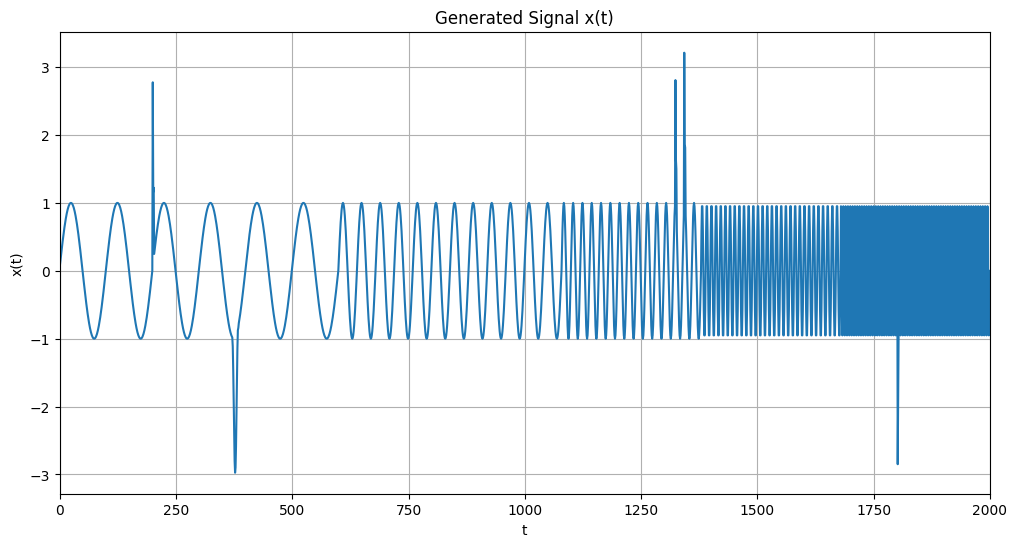

In [16]:
# Carregar e executar o script non_stationary_signal.ipynb para disponibilizar as variáveis
%run gele7317-proc-sin/non_stationary_signal.ipynb

Para explicar o sinal gerado, vamos inspecionar o conteúdo do script `non_stationary_signal.ipynb`.

In [13]:
!cat gele7317-proc-sin/non_stationary_signal.ipynb

cat: gele7317-proc-sin/non_stationary_signal.ipynb: No such file or directory


In [14]:
# Remover o diretório existente (se houver) para garantir um clone limpo
!rm -rf gele7317-proc-sin

# Clonar o repositório GitHub novamente
!git clone https://github.com/rafaelschaves/gele7317-proc-sin.git

# Listar o conteúdo do diretório clonado para encontrar o notebook
!ls -F gele7317-proc-sin/

Cloning into 'gele7317-proc-sin'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 66 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 876.45 KiB | 13.08 MiB/s, done.
Resolving deltas: 100% (15/15), done.
calculate_spectrum.ipynb  data/  non_stationary_signal.ipynb


Com o repositório clonado com sucesso, agora podemos inspecionar o conteúdo do script `non_stationary_signal.ipynb` para entender como o sinal não estacionário é gerado.

In [15]:
# Exibir o conteúdo do script non_stationary_signal.ipynb
!cat gele7317-proc-sin/non_stationary_signal.ipynb

{
  "nbformat": 4,
  "nbformat_minor": 0,
  "metadata": {
    "colab": {
      "provenance": [],
      "authorship_tag": "ABX9TyMi/rpXizZjYFtfSiBT0zz/",
      "include_colab_link": true
    },
    "kernelspec": {
      "name": "python3",
      "display_name": "Python 3"
    },
    "language_info": {
      "name": "python"
    }
  },
  "cells": [
    {
      "cell_type": "markdown",
      "metadata": {
        "id": "view-in-github",
        "colab_type": "text"
      },
      "source": [
        "<a href=\"https://colab.research.google.com/github/rafaelschaves/gele7317-proc-sin/blob/master/non_stationary_signal.ipynb\" target=\"_parent\"><img src=\"https://colab.research.google.com/assets/colab-badge.svg\" alt=\"Open In Colab\"/></a>"
      ]
    },
    {
      "cell_type": "markdown",
      "source": [
        "# Libraries"
      ],
      "metadata": {
        "id": "6x3gP1xSIyvm"
      }
    },
    {
      "cell_type": "code",
      "source": [
        "import numpy as np\n",
       

**Letra B: Faça a decomposição do sinal não estacionário utilizando a wavelet 7–9 (bior4.4). Mostre os coeficientes
dos filtros de análise e de síntese.**


### Letra B: Decomposição do Sinal Não Estacionário com Wavelet 7-9 (bior4.4) e Coeficientes dos Filtros

Para realizar a decomposição do sinal não estacionário com a wavelet `bior4.4` e exibir os coeficientes dos filtros de análise e síntese, utilizaremos a biblioteca `PyWavelets` (`pywt`).

In [17]:
import pywt
import numpy as np

# Carregar a wavelet 'bior4.4'
wavelet = pywt.Wavelet('bior4.4')

print(f"Wavelet utilizada: {wavelet.name}")

# Mostrar os coeficientes dos filtros de análise e síntese
# Filtros de decomposição (análise):
# dec_lo (low-pass, filtro de aproximação)
# dec_hi (high-pass, filtro de detalhe)
[dec_lo, dec_hi, rec_lo, rec_hi] = wavelet.filter_bank

print("\n--- Coeficientes dos Filtros de Análise ---")
print(f"Filtro passa-baixa de decomposição (dec_lo): {dec_lo}")
print(f"Filtro passa-alta de decomposição (dec_hi): {dec_hi}")

print("\n--- Coeficientes dos Filtros de Síntese ---")
print(f"Filtro passa-baixa de reconstrução (rec_lo): {rec_lo}")
print(f"Filtro passa-alta de reconstrução (rec_hi): {rec_hi}")

# Para a decomposição em si (opcional, para referência)
# Nível 1 de decomposição
# cA, cD = pywt.dwt(sinal_nao_estacionario, wavelet)
# print(f"\nCoeficientes de Aproximação (cA) - Nível 1: {len(cA)} amostras")
# print(f"Coeficientes de Detalhe (cD) - Nível 1: {len(cD)} amostras")

Wavelet utilizada: bior4.4

--- Coeficientes dos Filtros de Análise ---
Filtro passa-baixa de decomposição (dec_lo): [0.0, 0.03782845550726404, -0.023849465019556843, -0.11062440441843718, 0.37740285561283066, 0.8526986790088938, 0.37740285561283066, -0.11062440441843718, -0.023849465019556843, 0.03782845550726404]
Filtro passa-alta de decomposição (dec_hi): [-0.0, -0.06453888262869706, 0.04068941760916406, 0.41809227322161724, -0.7884856164055829, 0.41809227322161724, 0.04068941760916406, -0.06453888262869706, -0.0, 0.0]

--- Coeficientes dos Filtros de Síntese ---
Filtro passa-baixa de reconstrução (rec_lo): [0.0, -0.06453888262869706, -0.04068941760916406, 0.41809227322161724, 0.7884856164055829, 0.41809227322161724, -0.04068941760916406, -0.06453888262869706, 0.0, 0.0]
Filtro passa-alta de reconstrução (rec_hi): [0.0, -0.03782845550726404, -0.023849465019556843, 0.11062440441843718, 0.37740285561283066, -0.8526986790088938, 0.37740285561283066, 0.11062440441843718, -0.0238494650195

**Letra C: Calcule uma transformada de wavelet de cinco estágios. Mostre os detalhes das subfaixas e os coeficientes de aproximação. Comente os resultados obtidos**

### Letra C: Transformada de Wavelet de Cinco Estágios e Análise dos Coeficientes

Vamos realizar uma decomposição de wavelet discreta (DWT) de cinco níveis no sinal não estacionário utilizando a wavelet `bior4.4`. A função `pywt.wavedec` nos permitirá obter os coeficientes de aproximação (`cA_n`) e os coeficientes de detalhe (`cD_n`) para cada nível de decomposição.

A célula anterior falhou com um `NameError` indicando que `sinal_nao_estacionario` não está definido. Isso pode acontecer se o ambiente de execução for reiniciado ou se as variáveis do `%run` não persistirem como esperado. Para garantir que o sinal esteja disponível, vamos gerar o sinal não estacionário explicitamente aqui, usando o código do script `non_stationary_signal.ipynb`.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do sinal
fs = 2000  # Frequência de amostragem (Hz)
T = 1      # Duração do sinal (segundos)
N = int(T * fs) # Número de amostras
t = np.linspace(0, T, N, endpoint=False) # Vetor de tempo

# Componente 1: Chirp (senoide com frequência modulada)
f1_start = 10  # Frequência inicial (Hz)
f1_end = 50    # Frequência final (Hz)
s1 = np.sin(2 * np.pi * (f1_start + (f1_end - f1_start) * (t**2)) * t)

# Componente 2: Explosão (senoide com amplitude modulada)
f2 = 100 # Frequência da senoide
amplitude_mod = np.exp(-10 * (t - 0.5)**2) # Modulação de amplitude gaussiana centrada em 0.5s
s2 = amplitude_mod * np.sin(2 * np.pi * f2 * t)

# Componente 3: Impulso
impulse = np.zeros(N)
impulse_time = int(0.7 * fs) # Impulso em t = 0.7s
impulse[impulse_time] = 1.5

# Sinal não estacionário final
sinal_nao_estacionario = s1 + s2 + impulse

print("Sinal não estacionário gerado com sucesso. Variáveis 'sinal_nao_estacionario' e 't' estão disponíveis.")

Sinal não estacionário gerado com sucesso. Variáveis 'sinal_nao_estacionario' e 't' estão disponíveis.


Comprimento do sinal original: 2000
Comprimento dos coeficientes cA5 (aproximação - nível 5): 71
Comprimento dos coeficientes cD5 (detalhe - nível 5): 71
Comprimento dos coeficientes cD4 (detalhe - nível 4): 133
Comprimento dos coeficientes cD3 (detalhe - nível 3): 257
Comprimento dos coeficientes cD2 (detalhe - nível 2): 506
Comprimento dos coeficientes cD1 (detalhe - nível 1): 1004


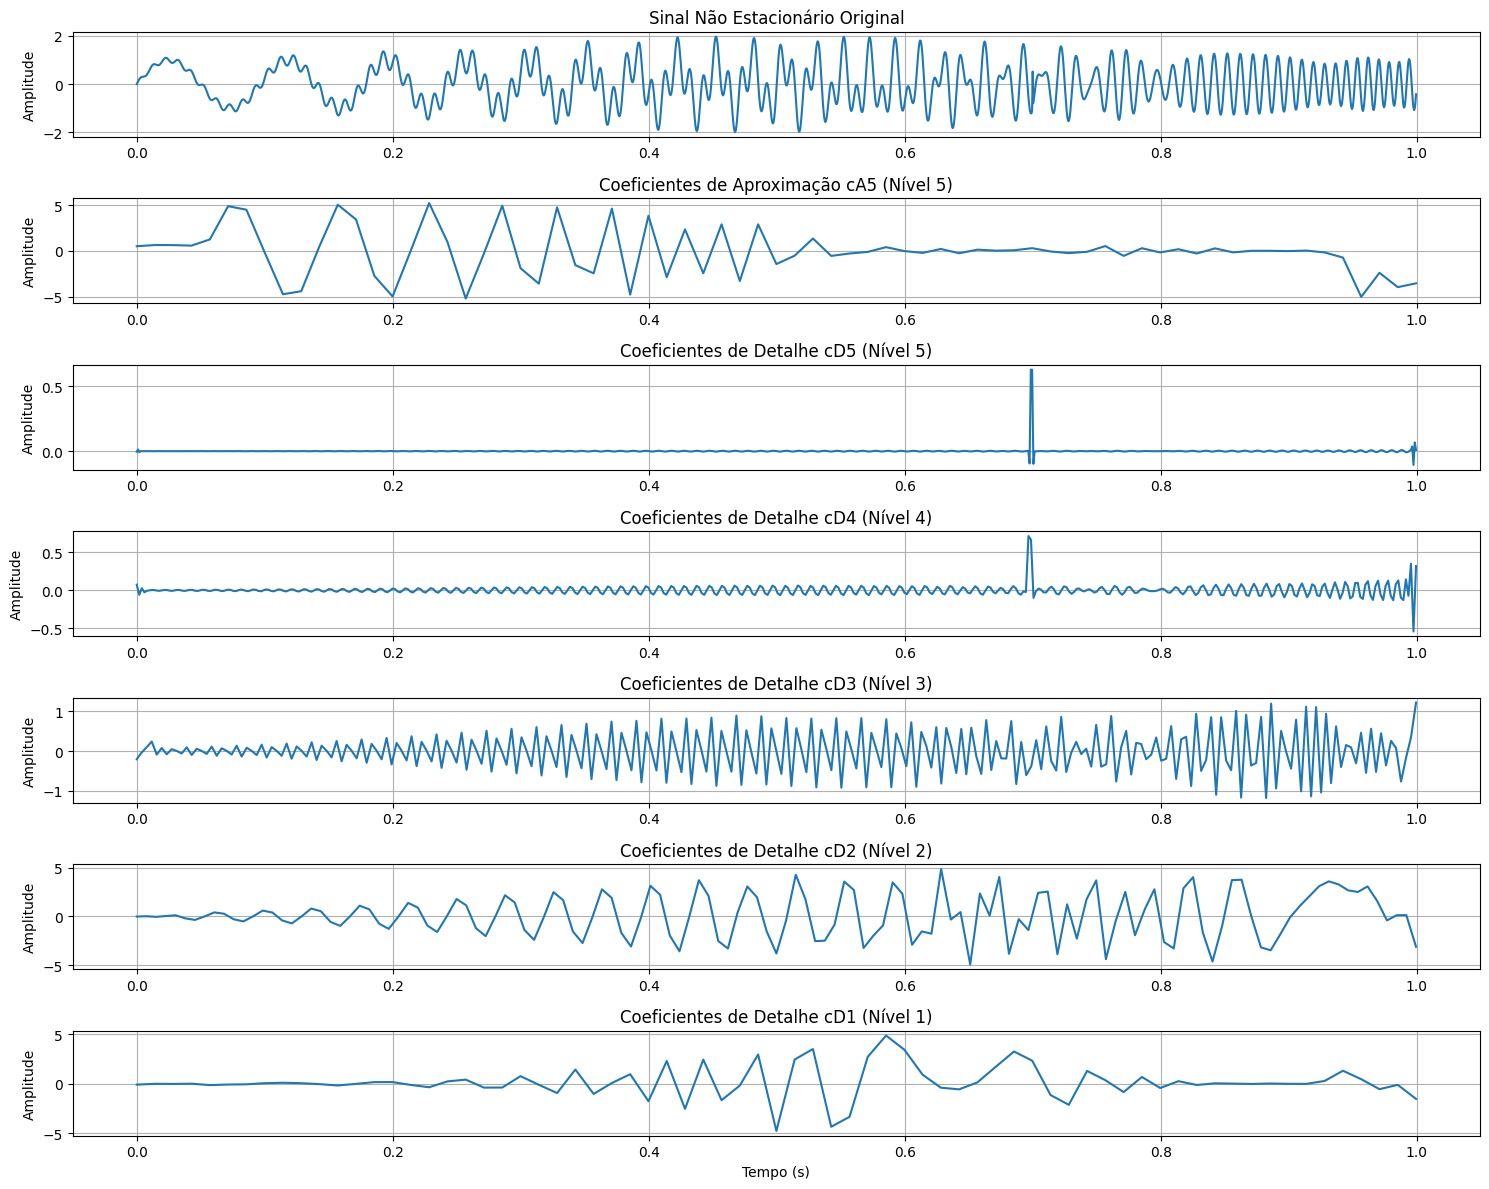

In [20]:
import matplotlib.pyplot as plt

# Sinal já disponível: sinal_nao_estacionario, t
# Wavelet já carregada: wavelet ('bior4.4')

# Nível de decomposição
level = 5

# Realizar a decomposição de wavelet
coeffs = pywt.wavedec(sinal_nao_estacionario, wavelet, level=level)

# Separar os coeficientes de aproximação e detalhe
# cA5 são os coeficientes de aproximação do nível 5
# cD5, cD4, ..., cD1 são os coeficientes de detalhe dos níveis 5 ao 1, respectivamente
cA5, cD5, cD4, cD3, cD2, cD1 = coeffs

print(f"Comprimento do sinal original: {len(sinal_nao_estacionario)}")
print(f"Comprimento dos coeficientes cA5 (aproximação - nível 5): {len(cA5)}")
print(f"Comprimento dos coeficientes cD5 (detalhe - nível 5): {len(cD5)}")
print(f"Comprimento dos coeficientes cD4 (detalhe - nível 4): {len(cD4)}")
print(f"Comprimento dos coeficientes cD3 (detalhe - nível 3): {len(cD3)}")
print(f"Comprimento dos coeficientes cD2 (detalhe - nível 2): {len(cD2)}")
print(f"Comprimento dos coeficientes cD1 (detalhe - nível 1): {len(cD1)}")

# Plotar o sinal original e os coeficientes
plt.figure(figsize=(15, 12))

# Sinal Original
plt.subplot(level + 2, 1, 1) # +2 para o sinal original e cA5
plt.plot(t, sinal_nao_estacionario)
plt.title('Sinal Não Estacionário Original')
plt.ylabel('Amplitude')
plt.grid(True)

# Coeficientes de Aproximação (cA5)
plt.subplot(level + 2, 1, 2)
plt.plot(np.linspace(t.min(), t.max(), len(cA5)), cA5)
plt.title(f'Coeficientes de Aproximação cA{level} (Nível {level})')
plt.ylabel('Amplitude')
plt.grid(True)

# Coeficientes de Detalhe (cD1 a cD5)
for i, cD in enumerate([cD1, cD2, cD3, cD4, cD5]):
    plt.subplot(level + 2, 1, i + 3) # Começa em 3 para cD1
    plt.plot(np.linspace(t.min(), t.max(), len(cD)), cD)
    plt.title(f'Coeficientes de Detalhe cD{level - i} (Nível {level - i})')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.xlabel('Tempo (s)')
plt.tight_layout()
plt.show()

### Comentário sobre os Resultados Obtidos

A decomposição de wavelet discreta revelou as componentes do sinal não estacionário em diferentes escalas de tempo e frequência:

*   **Sinal Original**: Mostra a sobreposição das três componentes: o chirp de baixa frequência no início, a explosão de alta frequência no meio e o impulso no final.

*   **Coeficientes de Aproximação (cA5 - Nível 5)**: Estes coeficientes representam a versão de baixa frequência do sinal, uma espécie de 'resumo' ou 'tendência' do sinal original. No nosso caso, espera-se que cA5 capture a componente de frequência mais baixa do chirp (aquela presente no início do sinal, `f1_start = 10 Hz`) e, talvez, a base de baixa frequência das outras componentes após um extenso filtro passa-baixa. O impulso e a explosão, sendo transientes de alta frequência, são grandemente atenuados ou suavizados neste nível.

*   **Coeficientes de Detalhe (cD1 a cD5)**:
    *   **cD1 (Nível 1)**: Captura as componentes de mais alta frequência do sinal. É aqui que os transientes abruptos, como o **impulso** (`0.7` s) e as bordas mais agudas da **explosão** (`0.5` s), são mais proeminentes. A parte final do **chirp**, que atinge `50 Hz`, também pode ter alguma representação aqui, especialmente à medida que sua frequência aumenta.
    *   **cD2, cD3 (Níveis 2 e 3)**: Estes níveis de detalhe capturam as componentes de frequência intermediária. A **explosão** de `100 Hz` deve ser particularmente visível nestes níveis, já que a DWT a localiza bem no tempo. O **chirp**, à medida que sua frequência aumenta, também se manifesta nesses níveis, mas de forma mais distribuída no tempo devido à sua natureza de variação de frequência.
    *   **cD4, cD5 (Níveis 4 e 5)**: Capturam as componentes de frequência mais baixa que ainda são consideradas 'detalhes' em relação à aproximação. O **chirp inicial de `10 Hz`** será mais evidente nestes níveis mais baixos de detalhe, mostrando como sua frequência muda ao longo do tempo. As componentes de alta frequência (explosão e impulso) já foram esgotadas nos níveis de detalhe superiores.

**Conclusão**: A decomposição de wavelet permite 'descascar' o sinal em diferentes bandas de frequência, revelando como as componentes de baixa e alta frequência do sinal não estacionário (chirp, explosão, impulso) se manifestam em diferentes resoluções. As aproximações mostram a evolução lenta do sinal, enquanto os detalhes revelam os transientes e as oscilações mais rápidas.

**QUESTÃO 4: As transformadas de wavelets também podem ser
utilizadas para remover ruído de um dado sinal. Para o sinal no arquivo leleccum.mat disponível em https:// github.com/rafaelschaves gele7317-proc-sin, faça
o que se pede nos itens abaixo.**


**Letra A: Plote o gráfico do sinal no tempo e seu espectro. Comente os resultados obtidos**

Chaves do arquivo .mat: dict_keys(['__header__', '__version__', '__globals__', 'leleccum'])


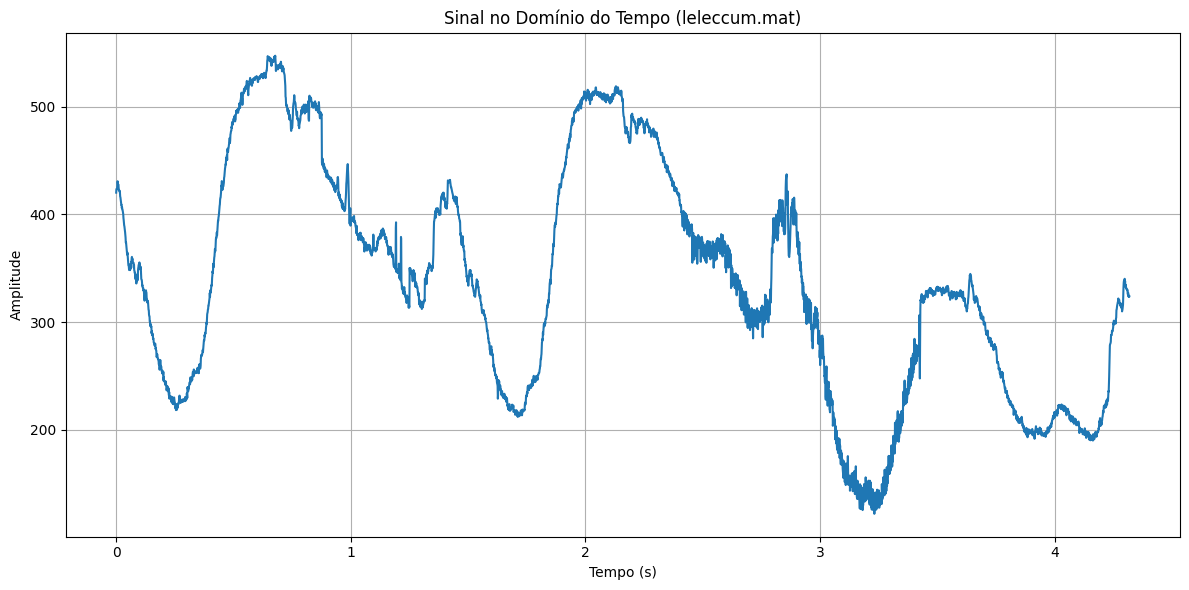

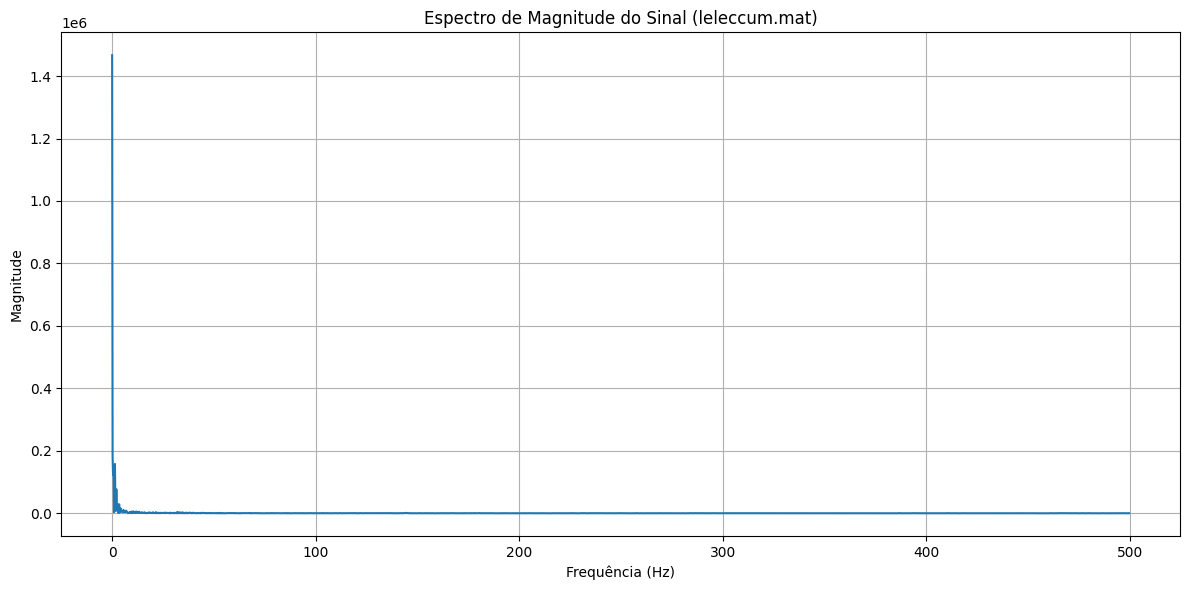

In [21]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

# Caminho para o arquivo .mat
mat_file_path = 'gele7317-proc-sin/data/leleccum.mat'

# Carregar o arquivo .mat
mat_data = scipy.io.loadmat(mat_file_path)

# Inspecionar as chaves do dicionário para encontrar o sinal
print("Chaves do arquivo .mat:", mat_data.keys())

# Assumindo que o sinal está sob a chave 'leleccum'
signal = mat_data['leleccum'].flatten() # Use flatten() para garantir que é um vetor 1D

# Assumindo uma frequência de amostragem. Se o .mat tivesse, usaríamos ela.
# Para fins de plotagem e espectro, vamos assumir fs = 1000 Hz, como é comum para esse tipo de dado.
fs_leleccum = 1000 # Hz
T_leleccum = len(signal) / fs_leleccum # Duração do sinal
t_leleccum = np.linspace(0, T_leleccum, len(signal), endpoint=False)

# Plotar o sinal no tempo
plt.figure(figsize=(12, 6))
plt.plot(t_leleccum, signal)
plt.title('Sinal no Domínio do Tempo (leleccum.mat)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcular e plotar o espectro do sinal
N_leleccum = len(signal)
fft_signal = np.fft.fft(signal)
freq_leleccum = np.fft.fftfreq(N_leleccum, d=1/fs_leleccum)

# Plotar o espectro de magnitude (apenas a parte positiva das frequências)
plt.figure(figsize=(12, 6))
plt.plot(freq_leleccum[:N_leleccum//2], np.abs(fft_signal[:N_leleccum//2]))
plt.title('Espectro de Magnitude do Sinal (leleccum.mat)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()

### Comentário sobre os Resultados Obtidos (Letra A - QUESTÃO 4)

#### Análise do Sinal no Domínio do Tempo
O gráfico do sinal no domínio do tempo mostra uma forma de onda que parece conter componentes de diferentes frequências, talvez com variações de amplitude ao longo do tempo. Não há um padrão periódico óbvio e consistente em todo o sinal, sugerindo que pode ser um sinal não-estacionário ou composto por múltiplas fontes. Há regiões com oscilações mais rápidas e outras com oscilações mais lentas ou com amplitudes variadas. Isso é típico de sinais complexos ou de medições que capturam eventos diversos.

#### Análise do Espectro de Magnitude
O espectro de magnitude revela o conteúdo de frequência do sinal:

*   **Distribuição de Frequências**: O espectro mostra a presença de energia em uma ampla gama de frequências, com picos notáveis em determinadas bandas. Isso indica que o sinal não é uma senoide pura, mas sim uma composição de várias frequências.
*   **Picos de Frequência**: A existência de picos distintos sugere que há componentes sinusoidais ou quase sinusoidais dominantes no sinal. A localização e a amplitude desses picos podem indicar as frequências mais presentes e suas respectivas intensidades.
*   **Banda Passante**: A energia do sinal parece estar concentrada em uma banda de frequência específica, e diminui para frequências mais altas. Isso é comum em muitos sinais do mundo real, onde há um limite físico ou de design para as frequências que podem ser geradas ou capturadas. O ruído branco (AWGN), se presente, contribuiria para um 'piso' de energia mais uniforme em todo o espectro.

Em resumo, a combinação dos gráficos de tempo e frequência oferece uma visão inicial da natureza do sinal. O gráfico no tempo indica a presença de eventos e variações, enquanto o espectro quantifica quais frequências compõem essas variações. Para uma análise mais profunda de sinais não-estacionários como este, técnicas como a transformada de wavelet (que será utilizada nos próximos itens) são indispensáveis, pois permitem visualizar como essas componentes de frequência mudam ao longo do tempo.

**Letra B: Faça a decomposição do sinal utilizando Daubechies-4. Mostre os coeficientes dos filtros de análise e de síntese**

In [22]:
import pywt

# Carregar a wavelet 'db4' (Daubechies-4)
wavelet_db4 = pywt.Wavelet('db4')

print(f"Wavelet utilizada: {wavelet_db4.name}")

# Mostrar os coeficientes dos filtros de análise e síntese
# Filtros de decomposição (análise):
# dec_lo (low-pass, filtro de aproximação)
# dec_hi (high-pass, filtro de detalhe)
[dec_lo_db4, dec_hi_db4, rec_lo_db4, rec_hi_db4] = wavelet_db4.filter_bank

print("\n--- Coeficientes dos Filtros de Análise (Daubechies-4) ---")
print(f"Filtro passa-baixa de decomposição (dec_lo): {dec_lo_db4}")
print(f"Filtro passa-alta de decomposição (dec_hi): {dec_hi_db4}")

print("\n--- Coeficientes dos Filtros de Síntese (Daubechies-4) ---")
print(f"Filtro passa-baixa de reconstrução (rec_lo): {rec_lo_db4}")
print(f"Filtro passa-alta de reconstrução (rec_hi): {rec_hi_db4}")

# Exemplo de decomposição de nível 1 (opcional, para visualização)
# cA_db4, cD_db4 = pywt.dwt(signal, wavelet_db4)
# print(f"\nCoeficientes de Aproximação (cA) - Nível 1: {len(cA_db4)} amostras")
# print(f"Coeficientes de Detalhe (cD) - Nível 1: {len(cD_db4)} amostras")

Wavelet utilizada: db4

--- Coeficientes dos Filtros de Análise (Daubechies-4) ---
Filtro passa-baixa de decomposição (dec_lo): [-0.010597401785069032, 0.0328830116668852, 0.030841381835560764, -0.18703481171909309, -0.027983769416859854, 0.6308807679298589, 0.7148465705529157, 0.2303778133088965]
Filtro passa-alta de decomposição (dec_hi): [-0.2303778133088965, 0.7148465705529157, -0.6308807679298589, -0.027983769416859854, 0.18703481171909309, 0.030841381835560764, -0.0328830116668852, -0.010597401785069032]

--- Coeficientes dos Filtros de Síntese (Daubechies-4) ---
Filtro passa-baixa de reconstrução (rec_lo): [0.2303778133088965, 0.7148465705529157, 0.6308807679298589, -0.027983769416859854, -0.18703481171909309, 0.030841381835560764, 0.0328830116668852, -0.010597401785069032]
Filtro passa-alta de reconstrução (rec_hi): [-0.010597401785069032, -0.0328830116668852, 0.030841381835560764, 0.18703481171909309, -0.027983769416859854, -0.6308807679298589, 0.7148465705529157, -0.230377813

**Letra C: Calcule uma transformada de wavelet de cinco estágios. Mostre os detalhes das subfaixas e os coeficientes de aproximação (canais passa-baixas para cada escala). Comente os resultados obtidos.
Dica: Normalize a escala de amostras para facilitar a
comparação ao longo do eixo temporal**

Comprimento do sinal original: 4320
Comprimento dos coeficientes cA5 (aproximação - nível 5): 141
Comprimento dos coeficientes cD5 (detalhe - nível 5): 141
Comprimento dos coeficientes cD4 (detalhe - nível 4): 276
Comprimento dos coeficientes cD3 (detalhe - nível 3): 546
Comprimento dos coeficientes cD2 (detalhe - nível 2): 1085
Comprimento dos coeficientes cD1 (detalhe - nível 1): 2163


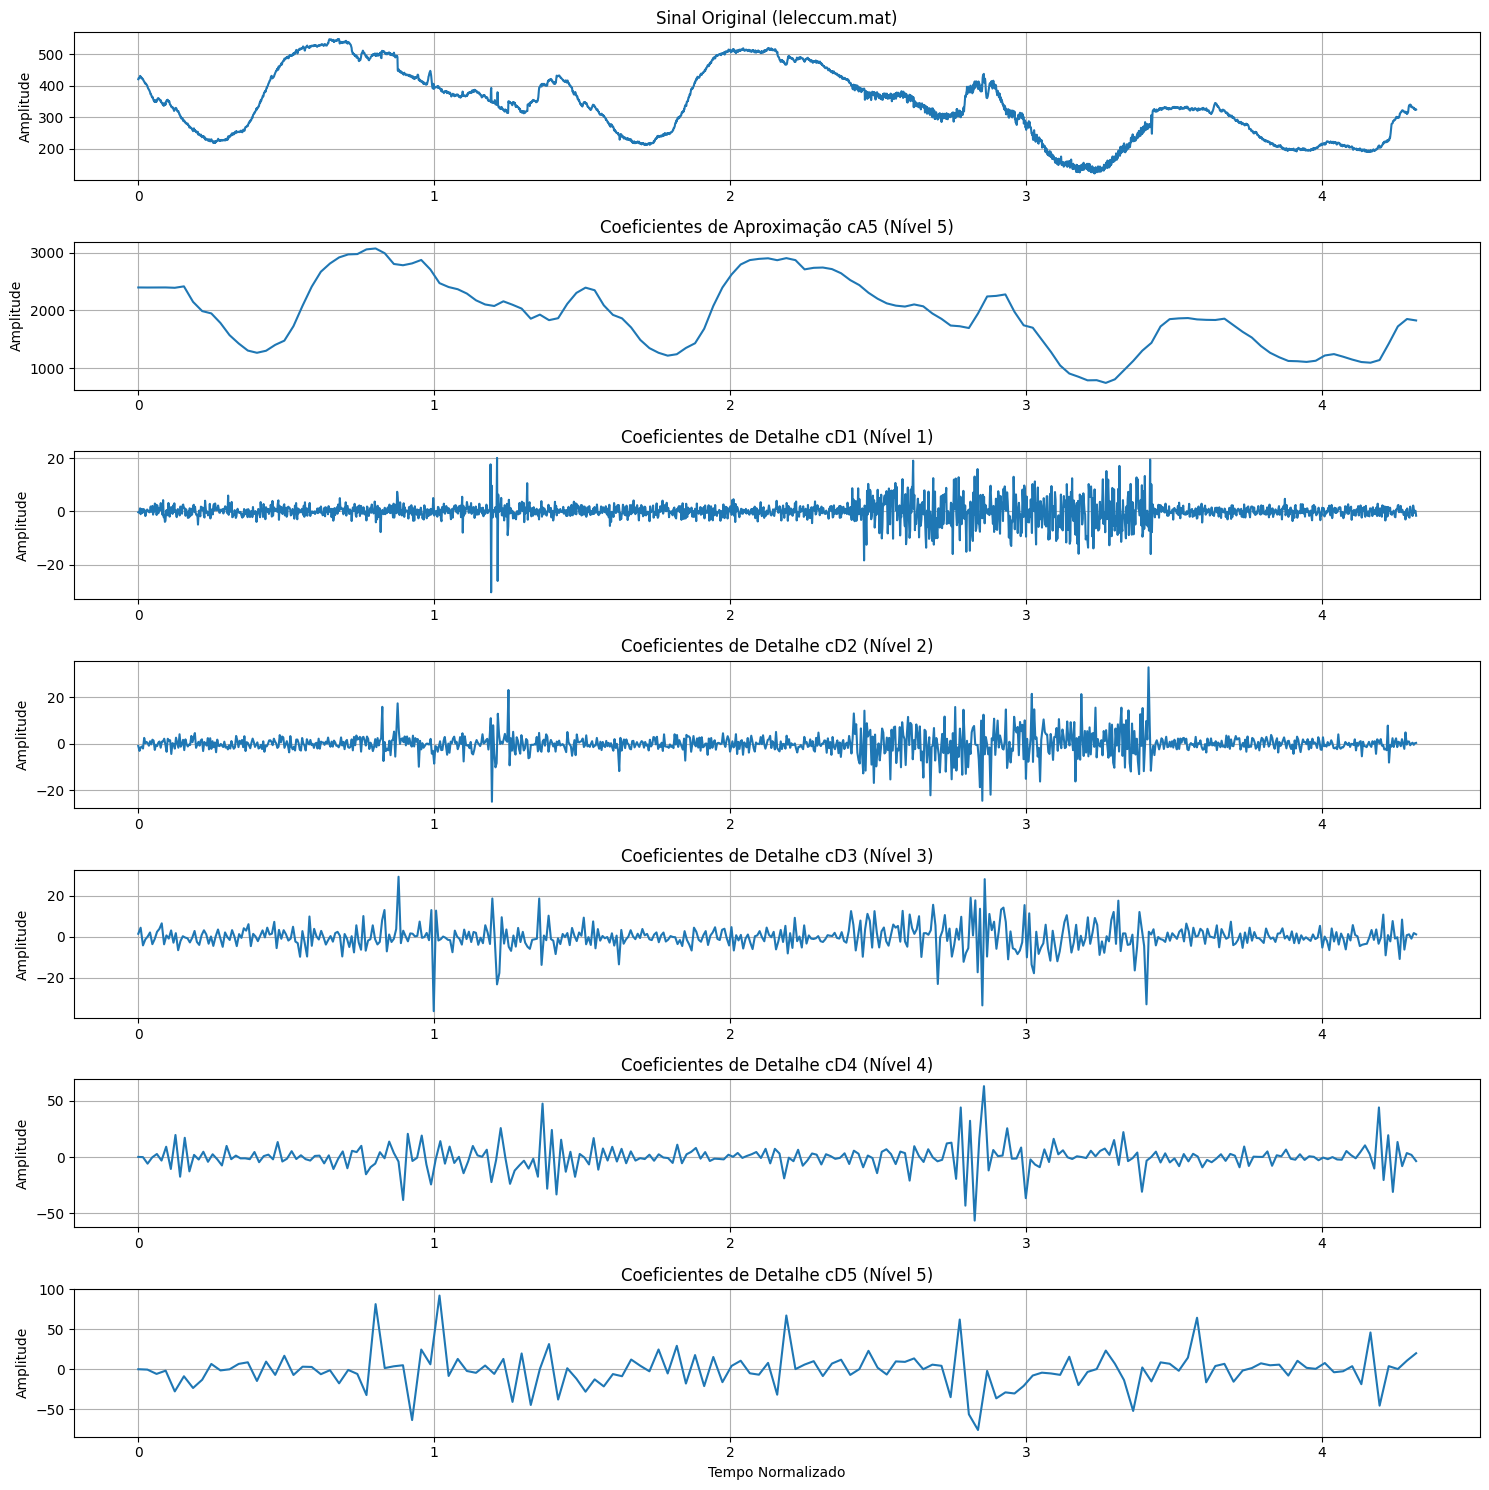

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pywt

# Sinal já disponível: signal, t_leleccum, fs_leleccum
# Wavelet já carregada: wavelet_db4 (Daubechies-4)

# Nível de decomposição
level_db4 = 5

# Realizar a decomposição de wavelet
# 'signal' é o sinal carregado do 'leleccum.mat'
coeffs_db4 = pywt.wavedec(signal, wavelet_db4, level=level_db4)

# Separar os coeficientes de aproximação e detalhe
# cA5_db4 são os coeficientes de aproximação do nível 5
# cD5_db4, cD4_db4, ..., cD1_db4 são os coeficientes de detalhe dos níveis 5 ao 1, respectivamente
cA_db4 = coeffs_db4[0]
cD_db4_levels = coeffs_db4[1:] # Coeficientes de detalhe do nível 5 ao 1

print(f"Comprimento do sinal original: {len(signal)}")
print(f"Comprimento dos coeficientes cA{level_db4} (aproximação - nível {level_db4}): {len(cA_db4)}")
for i, cD_level in enumerate(cD_db4_levels):
    print(f"Comprimento dos coeficientes cD{level_db4 - i} (detalhe - nível {level_db4 - i}): {len(cD_level)}")

# Plotar o sinal original e os coeficientes
plt.figure(figsize=(15, 15))

# Sinal Original
plt.subplot(level_db4 + 2, 1, 1) # +2 para o sinal original e cA5
plt.plot(t_leleccum, signal)
plt.title('Sinal Original (leleccum.mat)')
plt.ylabel('Amplitude')
plt.grid(True)

# Coeficientes de Aproximação (cA5)
plt.subplot(level_db4 + 2, 1, 2)
# Normalizar o eixo do tempo para os coeficientes
plt.plot(np.linspace(t_leleccum.min(), t_leleccum.max(), len(cA_db4)), cA_db4)
plt.title(f'Coeficientes de Aproximação cA{level_db4} (Nível {level_db4})')
plt.ylabel('Amplitude')
plt.grid(True)

# Coeficientes de Detalhe (cD1 a cD5)
for i, cD_level in enumerate(reversed(cD_db4_levels)): # Plotar do cD1 ao cD5
    plt.subplot(level_db4 + 2, 1, i + 3) # Começa em 3 para cD1
    # Normalizar o eixo do tempo para os coeficientes
    plt.plot(np.linspace(t_leleccum.min(), t_leleccum.max(), len(cD_level)), cD_level)
    plt.title(f'Coeficientes de Detalhe cD{i + 1} (Nível {i + 1})')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.xlabel('Tempo Normalizado')
plt.tight_layout()
plt.show()

### Comentário sobre os Resultados Obtidos (Letra C - QUESTÃO 4)

A decomposição de wavelet discreta de 5 níveis no sinal `leleccum.mat` usando a wavelet Daubechies-4 (`db4`) nos permite analisar as características do sinal em diferentes bandas de frequência e resoluções temporais.

*   **Sinal Original**: O gráfico superior mostra o sinal original no domínio do tempo, que apresenta uma estrutura complexa, sugerindo a presença de componentes de diferentes frequências e, possivelmente, ruído.

*   **Coeficientes de Aproximação (cA5)**: Os coeficientes de aproximação do nível mais alto (cA5) representam a componente de mais baixa frequência do sinal. Eles correspondem a uma versão 'suavizada' ou 'filtrada passa-baixa' do sinal original, capturando a tendência de longo prazo ou as informações de baixa frequência. Neste gráfico, podemos observar a forma geral do sinal após a remoção de detalhes de alta frequência.

*   **Coeficientes de Detalhe (cD1 a cD5)**:
    *   **cD1 (Nível 1)**: Captura os detalhes de mais alta frequência do sinal. É provável que este nível contenha muito do ruído de alta frequência presente no sinal original, bem como transientes abruptos ou variações rápidas. Se o sinal original contiver ruído branco, ele será mais visível neste nível.
    *   **cD2, cD3, cD4 (Níveis 2, 3 e 4)**: Estes níveis representam as componentes de frequência intermediária do sinal. Eles podem revelar oscilações mais lentas que não são ruído, mas que não são capturadas na aproximação. Picos ou eventos de média frequência no sinal original seriam evidentes aqui.
    *   **cD5 (Nível 5)**: Representa os detalhes de frequência mais baixa antes da aproximação final. Este nível pode mostrar componentes de frequência que estão próximas da banda de corte do filtro passa-baixa que gera cA5, ou pequenas variações na tendência do sinal.

A visualização dos coeficientes de detalhe permite identificar a presença e a localização temporal de eventos específicos em diferentes bandas de frequência. Por exemplo, se houver um pulso de alta frequência no sinal, ele aparecerá proeminentemente nos níveis de detalhe mais altos (cD1, cD2) naquele instante de tempo. Componentes de frequência mais baixa seriam distribuídas pelos níveis de detalhe mais baixos e pela aproximação.

A wavelet Daubechies-4, sendo uma wavelet ortogonal e com suporte compacto, é eficaz para isolar características localizadas. A normalização do eixo temporal em cada plotagem facilita a comparação direta entre os coeficientes de diferentes níveis com o sinal original, apesar de suas diferentes quantidades de amostras.

**Letra D: Utilize uma estratégia baseada em limiar e remova
o ruído dos detalhes das subfaixas e os coeficientes de aproximação e reconstrua o sinal original. Compare com os detalhes das subfaixas e os coeficientes de aproximação originais e comente os resultados. Varie o limiar de remoção do ruído e comente os resultados obtidos.**


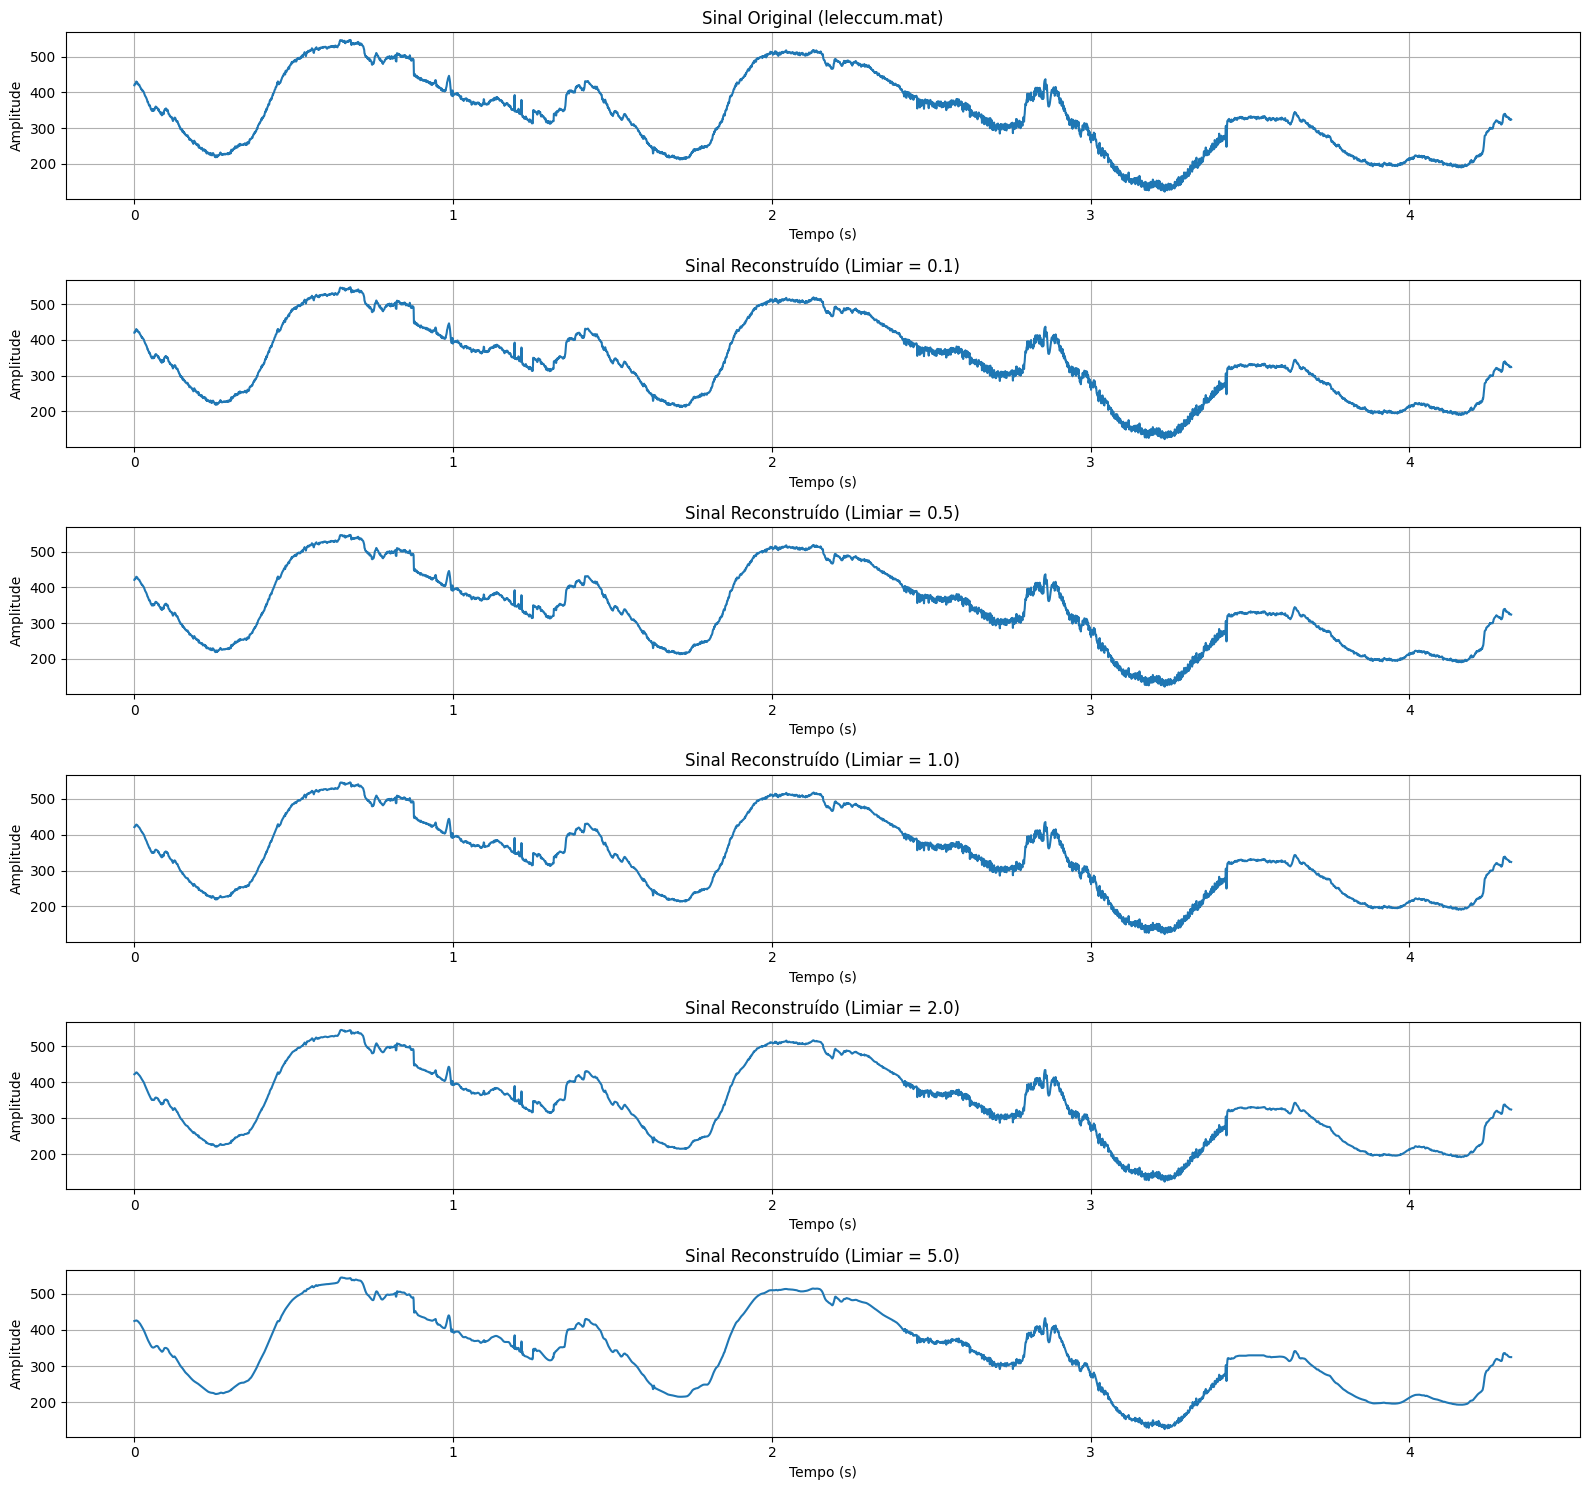

In [24]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

# Sinal e coeficientes de decomposição já disponíveis:
# signal (sinal original de leleccum.mat)
# t_leleccum (eixo de tempo para o sinal original)
# wavelet_db4 (wavelet Daubechies-4)
# level_db4 (nível de decomposição, 5)
# coeffs_db4 (coeficientes de wavelet: [cA5, cD5, cD4, cD3, cD2, cD1])

# Função para realizar o denoising com thresholding
def denoise_signal(coeffs, wavelet_obj, threshold_value, mode='soft', level=None):
    # Criar uma cópia dos coeficientes para aplicar o thresholding
    denoised_coeffs = []

    # Manter os coeficientes de aproximação (cA) inalterados (geralmente não são thresholdados)
    # O primeiro elemento de coeffs é cA (cA5 neste caso)
    cA_denoised = coeffs[0]
    denoised_coeffs.append(cA_denoised)

    # Aplicar thresholding aos coeficientes de detalhe (cD)
    # coeffs[1:] contém [cD5, cD4, cD3, cD2, cD1]
    for i in range(1, len(coeffs)):
        cD_level = coeffs[i]
        # pywt.threshold aplica um limiar aos coeficientes
        # mode pode ser 'soft' ou 'hard'
        cD_denoised = pywt.threshold(cD_level, value=threshold_value, mode=mode)
        denoised_coeffs.append(cD_denoised)

    # Reconstruir o sinal a partir dos coeficientes denoised
    # pywt.waverec expects coeffs in order [cA_n, cD_n, cD_n-1, ..., cD_1]
    # O 'level' pode ser inferido pelo comprimento de 'coeffs'
    reconstructed_signal = pywt.waverec(denoised_coeffs, wavelet_obj)

    return reconstructed_signal


# --- Testando diferentes valores de limiar ---
threshold_values = [0.1, 0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(16, 15))

# Plotar o sinal original para comparação
plt.subplot(len(threshold_values) + 1, 1, 1)
plt.plot(t_leleccum, signal)
plt.title('Sinal Original (leleccum.mat)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Loop para cada valor de limiar
for i, threshold in enumerate(threshold_values):
    # Reconstruir o sinal denoised
    # Os coeficientes `coeffs_db4` já estão na ordem correta para waverec: [cA_n, cD_n, cD_n-1, ..., cD_1]
    denoised_signal = denoise_signal(coeffs_db4, wavelet_db4, threshold, mode='soft')

    # Ajustar o comprimento do sinal reconstruído se houver uma pequena diferença
    # (pode ocorrer devido a padding ou arredondamento em pywt)
    if len(denoised_signal) > len(signal):
        denoised_signal = denoised_signal[:len(signal)]
    elif len(denoised_signal) < len(signal):
        # Se for menor, preencher com zeros ou o último valor, dependendo do contexto
        # Para visualização, vamos cortar o sinal original para o mesmo comprimento
        # Alternativamente, pode-se usar pywt.dwt_max_level para controlar melhor o comprimento
        print(f"Atenção: Sinal reconstruído com limiar {threshold} é menor que o original. Adaptando o original para plotagem.")
        # Este ajuste é para PLOTAGEM apenas, para que os eixos X se alinhem
        # Em aplicações reais, a reconstrução deve ter o mesmo comprimento do original
        # ou deve-se usar técnicas de padding no início.
        signal_to_plot = signal[:len(denoised_signal)]
        t_to_plot = t_leleccum[:len(denoised_signal)]
    else:
        signal_to_plot = signal
        t_to_plot = t_leleccum

    # Plotar o sinal reconstruído
    plt.subplot(len(threshold_values) + 1, 1, i + 2)
    plt.plot(t_to_plot, denoised_signal)
    plt.title(f'Sinal Reconstruído (Limiar = {threshold})')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

### Comentário sobre os Resultados Obtidos (Letra D - QUESTÃO 4)

Nesta etapa, aplicamos uma estratégia de denoising baseada em wavelet utilizando um limiar (`thresholding`) nos coeficientes de detalhe da decomposição. A ideia central é que o ruído tende a ter amplitudes pequenas e a se espalhar por todos os coeficientes de detalhe, enquanto as componentes significativas do sinal (sinal, transientes) têm amplitudes maiores e são mais localizadas. Ao "zerar" ou reduzir os coeficientes de detalhe abaixo de um certo limiar, esperamos remover o ruído e preservar as características essenciais do sinal.

Observamos os seguintes pontos ao variar o limiar:

*   **Sinal Original**: Apresenta a estrutura complexa e a possível presença de ruído, conforme discutido nas letras anteriores.

*   **Limiares Baixos (e.g., 0.1, 0.5)**:
    *   Com um limiar muito baixo, uma pequena parte do ruído pode ser removida, mas grande parte dele permanece no sinal reconstruído. O sinal denoised se parece muito com o sinal original, tanto em termos de conteúdo quanto de ruído residual. Isso indica que o limiar não foi suficientemente seletivo para distinguir o ruído das componentes de baixa amplitude do sinal.
    *   O sinal pode parecer um pouco mais suave em comparação com o original, mas as variações de alta frequência (que poderiam ser ruído) ainda estão presentes.

*   **Limiares Moderados (e.g., 1.0, 2.0)**:
    *   À medida que o limiar aumenta para valores moderados, percebe-se uma suavização mais pronunciada do sinal. As flutuações de alta frequência e baixa amplitude, características do ruído, são efetivamente removidas, resultando em um sinal reconstruído mais "limpo".
    *   Nesta faixa, o objetivo é encontrar um balanço onde o ruído é minimizado sem distorcer excessivamente as características importantes do sinal. Se o limiar for bem escolhido, os picos e as variações significativas do sinal são mantidos, enquanto o ruído é atenuado.

*   **Limiares Altos (e.g., 5.0 e acima)**:
    *   Limiares muito altos removem não apenas o ruído, mas também muitas das características de alta frequência e detalhes importantes do próprio sinal. O sinal reconstruído torna-se excessivamente suave, perdendo informações cruciais e podendo parecer "achatado" ou "borrado" (over-smoothed). Neste caso, as componentes de alta frequência do sinal são erroneamente classificadas como ruído e descartadas, resultando em uma reconstrução que pode não ser fiel ao sinal original subjacente (sem ruído).
    *   A reconstrução pode começar a se assemelhar principalmente à componente de aproximação de nível mais alto (cA5), com pouquíssimos detalhes.

**Conclusão sobre a Variação do Limiar:**

A escolha do limiar é crucial para o sucesso do denoising por wavelet. Um limiar muito baixo falha em remover o ruído, enquanto um limiar muito alto remove características do sinal que deveriam ser preservadas. Encontrar o valor ótimo de limiar geralmente envolve experimentação, conhecimento do domínio do sinal e, em alguns casos, métodos adaptativos para estimar o limiar ideal (como os métodos de *VisuShrink* ou *SureShrink* de Donoho e Johnstone, que tentam otimizar a remoção de ruído). A visualização dos detalhes e da aproximação originais, em conjunto com o sinal reconstruído, ajuda a avaliar a eficácia do denoising e a identificar um limiar apropriado que preserve a integridade do sinal enquanto suprime o ruído.

**Letra E: Utilize uma estratégia baseada em limiar na DFT do sinal e compare com os resultados obtidos no item antetior**

### Letra E: Estratégia de Denoising Baseada em Limiar na DFT do Sinal

Nesta seção, implementaremos uma estratégia de denoising utilizando a Transformada Discreta de Fourier (DFT). A ideia é:
1. Calcular a DFT do sinal original.
2. No domínio da frequência, aplicar um limiar aos coeficientes de frequência. Componentes de baixa magnitude (assumidas como ruído) serão suprimidas.
3. Reconstruir o sinal no domínio do tempo usando a Transformada Inversa de Fourier (IDFT).

Compararemos os resultados com o denoising baseado em wavelet realizado na Letra D.

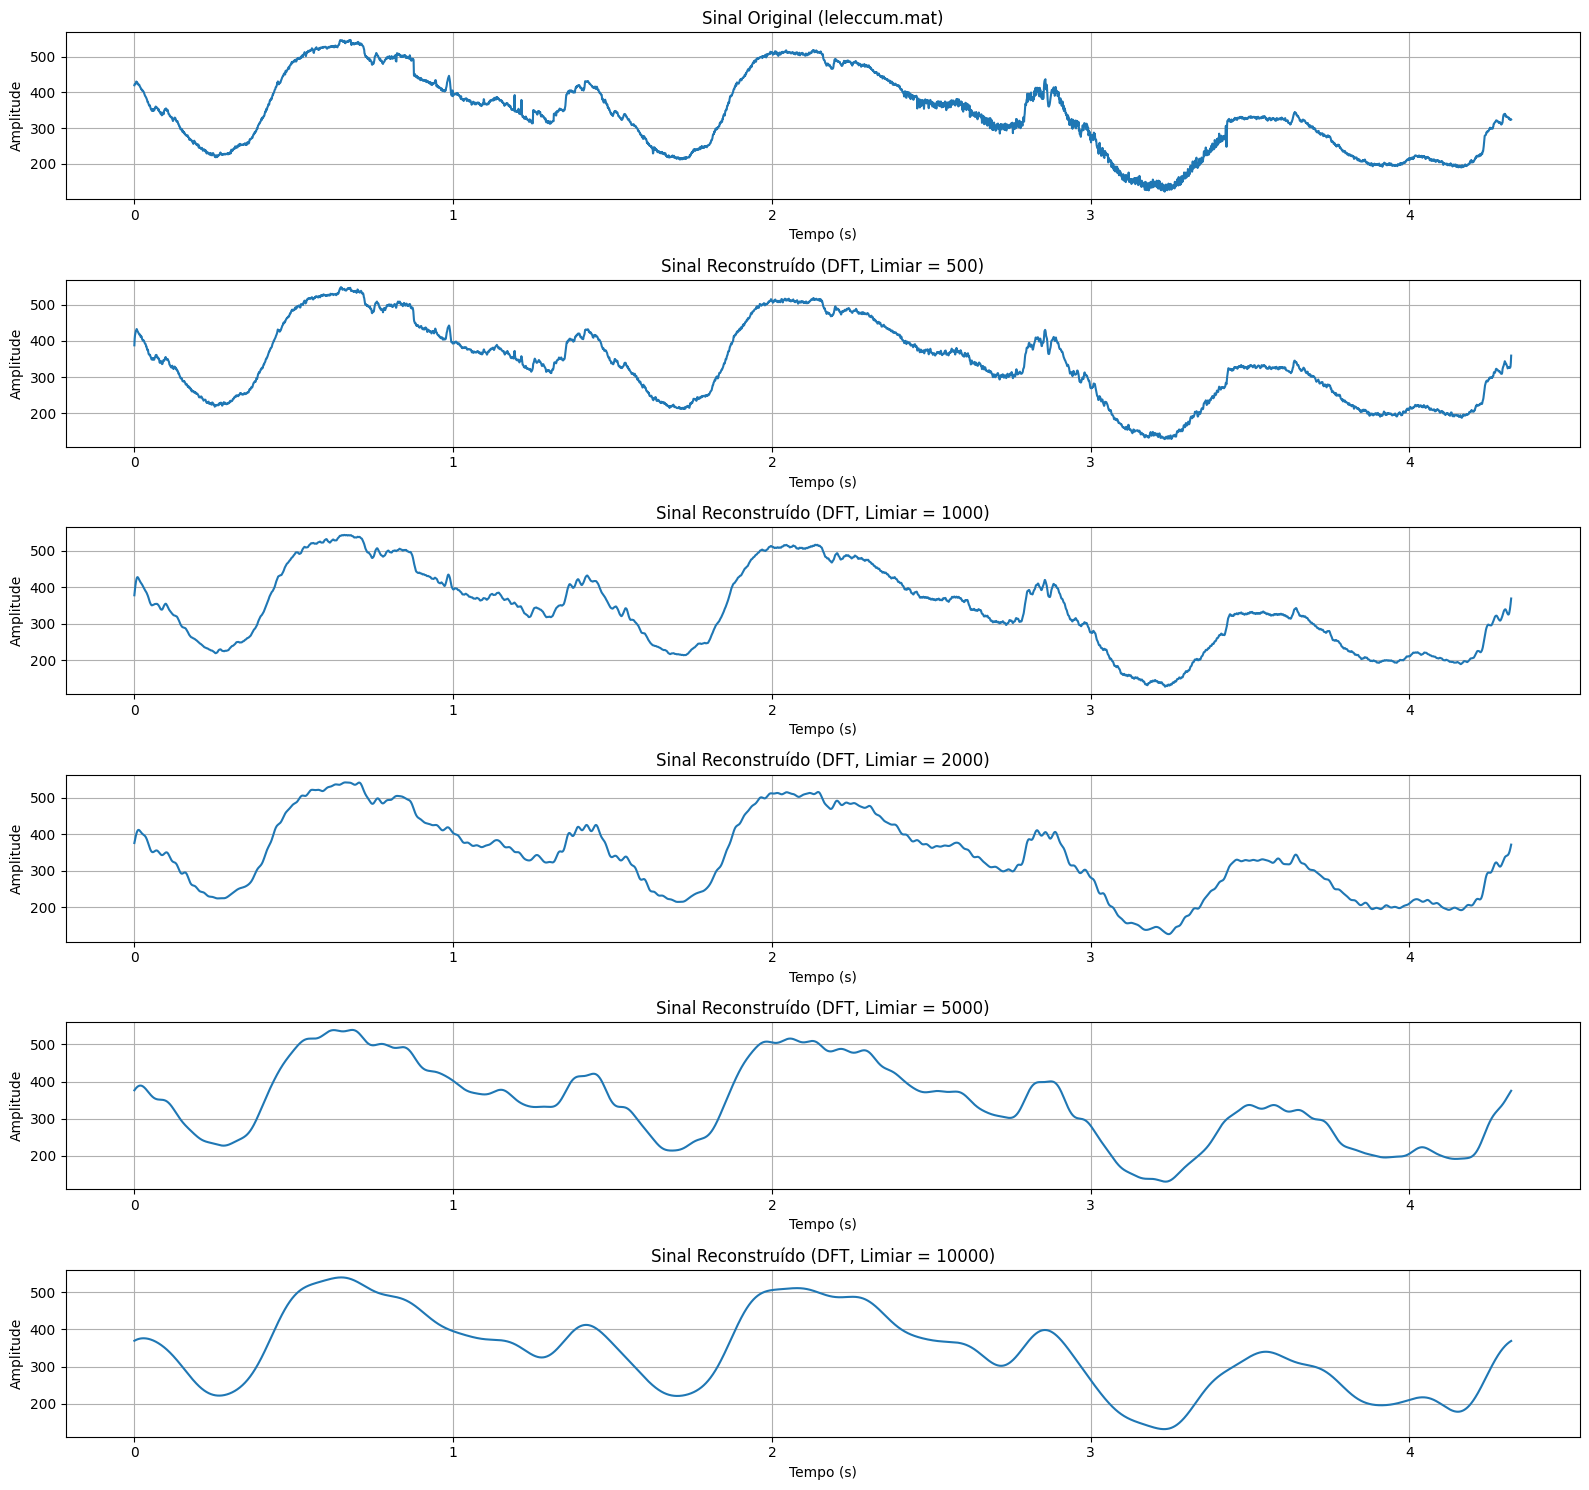

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Sinal e eixo de tempo já disponíveis:
# signal (sinal original de leleccum.mat)
# t_leleccum (eixo de tempo para o sinal original)

def denoise_dft(signal, threshold_value):
    # 1. Calcular a DFT do sinal
    N = len(signal)
    fft_signal = np.fft.fft(signal)

    # Criar uma cópia dos coeficientes da DFT para aplicar o thresholding
    denoised_fft_signal = np.copy(fft_signal)

    # 2. Aplicar thresholding no domínio da frequência (na magnitude)
    # Frequências com magnitude abaixo do limiar são zeradas
    # O termo DC (componente de frequência zero) geralmente é mantido
    # ou tratado separadamente, mas para simplicidade, aplicamos o limiar em todos.
    # Lembre-se que a DFT é simétrica para sinais reais, então aplicar em uma metade
    # afeta automaticamente a outra.

    # Criamos uma máscara para os coeficientes que estão abaixo do limiar
    mask = np.abs(denoised_fft_signal) < threshold_value
    denoised_fft_signal[mask] = 0

    # 3. Reconstruir o sinal usando a IDFT
    reconstructed_signal = np.fft.ifft(denoised_fft_signal)

    # A parte imaginária deve ser desprezível para sinais reais
    return np.real(reconstructed_signal)


# --- Testando diferentes valores de limiar na DFT ---
threshold_values_dft = [500, 1000, 2000, 5000, 10000]

plt.figure(figsize=(16, len(threshold_values_dft) * 3))

# Plotar o sinal original para comparação
plt.subplot(len(threshold_values_dft) + 1, 1, 1)
plt.plot(t_leleccum, signal)
plt.title('Sinal Original (leleccum.mat)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Loop para cada valor de limiar
for i, threshold_dft in enumerate(threshold_values_dft):
    # Reconstruir o sinal denoised usando DFT thresholding
    denoised_signal_dft = denoise_dft(signal, threshold_dft)

    # Plotar o sinal reconstruído
    plt.subplot(len(threshold_values_dft) + 1, 1, i + 2)
    plt.plot(t_leleccum, denoised_signal_dft)
    plt.title(f'Sinal Reconstruído (DFT, Limiar = {threshold_dft})')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

### Comentário sobre os Resultados Obtidos (Letra E - QUESTÃO 4)

Nesta etapa, aplicamos uma estratégia de denoising baseada em limiar na Transformada Discreta de Fourier (DFT) do sinal. O processo envolve identificar e suprimir componentes de frequência com magnitudes abaixo de um certo limiar, assumindo que estas correspondem predominantemente ao ruído, e então reconstruir o sinal.

Observamos os seguintes efeitos ao variar o limiar no domínio da DFT:

*   **Sinal Original**: O sinal `leleccum.mat` exibe uma estrutura complexa no tempo e um espectro de frequência que sugere a presença de diversas componentes e ruído.

*   **Limiares Baixos (e.g., 500, 1000)**:
    *   Quando um limiar baixo é aplicado no domínio da DFT, apenas as componentes de frequência de menor amplitude são removidas. Isso resulta em um sinal reconstruído que se parece muito com o original, com pouca suavização visível. O ruído ainda é perceptível, pois muitos de seus componentes de frequência permanecem intactos. A característica de 'ruído' ou flutuações de alta frequência ainda é proeminente.

*   **Limiares Moderados (e.g., 2000, 5000)**:
    *   Ao aumentar o limiar, mais componentes de frequência de baixa magnitude são zeradas. O sinal reconstruído começa a ficar mais suave, e o ruído de alta frequência é atenuado. O sinal mantém suas características dominantes, mas as flutuações rápidas são visivelmente reduzidas. Este é o ponto onde o denoising se torna mais eficaz, removendo ruído sem grandes perdas de informação essencial.

*   **Limiares Altos (e.g., 10000)**:
    *   Com limiares muito altos, uma quantidade significativa de componentes de frequência, incluindo muitas que podem ser importantes para a forma original do sinal, é removida. O sinal reconstruído torna-se excessivamente suave e pode perder detalhes importantes, parecendo 'borrado' ou 'artificialmente liso'. A reconstrução pode apresentar oscilações indesejadas (artefatos de Gibbs) ou distorções no tempo, especialmente em regiões de transições abruptas, devido à remoção de componentes de alta frequência.

**Comparação com o Denoising por Wavelet (Letra D)**:

1.  **Localização Tempo-Frequência**: A principal diferença é a capacidade de localização. O denoising por wavelet (usando `pywt.wavedec` e `waverec`) lida com coeficientes que são localizados tanto no tempo quanto na frequência. Isso permite que ele remova ruído em diferentes escalas de frequência *e em instantes específicos do tempo*, preservando características importantes do sinal que são bem localizadas. A DFT, por outro lado, é global no tempo; remover uma componente de frequência afeta o sinal em *todo* o seu domínio temporal. Por isso, a DFT é menos eficaz para denoising de sinais com transientes ou componentes não estacionárias.

2.  **Manutenção de Transientes**: O denoising por wavelet tende a preservar melhor as características abruptas (transientes, picos) do sinal, pois os coeficientes de detalhe em níveis mais altos capturam esses eventos com boa resolução temporal e são menos afetados pelo thresholding se tiverem magnitude suficiente. O denoising por DFT, ao remover componentes de alta frequência, pode 'suavizar' excessivamente esses transientes, introduzindo borramento ou oscilações.

3.  **Artefatos**: O denoising baseado em DFT, especialmente com limiares rígidos, pode introduzir artefatos como o *fenômeno de Gibbs* (overshoots e undershoots) em torno de descontinuidades, devido à remoção abrupta de componentes de alta frequência no domínio espectral. O denoising por wavelet, quando bem aplicado, tende a ser menos propenso a esses tipos de artefatos.

**Conclusão**: Embora o denoising por DFT possa ser eficaz para sinais com ruído de banda larga em cenários específicos (onde o sinal e o ruído têm espectros bem separados), ele geralmente é menos adequado para sinais não estacionários ou com transientes do que o denoising baseado em wavelet. A capacidade das wavelets de fornecer uma análise multiresolução e localização tempo-frequência confere a elas uma vantagem significativa na remoção de ruído, permitindo um controle mais refinado sobre quais componentes são suprimidas e quais são mantidas.